# EDA da base de datos

Script para a análise descritiva dos datos do TFM. Análise Clúster, análise temporal e detección de atípicos mediante Isolation Forest.

Comézase cargando as librarías precisas:

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dateparser
import seaborn as sns
import scipy.stats as stats
import prince
from sklearn.covariance import MinCovDet
from datetime import datetime
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.dates as mdates
from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from statsmodels.api import nonparametric
from sklearn.ensemble import IsolationForest

## Lectura de datos

In [4]:
datos = pd.read_csv('TFM Diego_cluster_Tabla-2.csv', sep = ',', decimal='.')

nombres_unicos = datos['client_name_complete'].unique()
mapeo_clientes = {nombre: f'Cliente {i+1}' for i, nombre in enumerate(nombres_unicos)}
datos['client_name_complete'] = datos['client_name_complete'].map(mapeo_clientes)

In [5]:
datos.shape

(21271, 15)

Temos 21271 observacións.

In [6]:
datos.dtypes

id_trucksters            object
contract                 object
lane_zipcode             object
client_name_complete     object
client_price            float64
empty_km                  int64
loaded_km                 int64
po_price_empty          float64
po_price_loaded         float64
direction                object
origin_country           object
destination_country      object
origin_zipcode           object
destination_zipcode      object
route_start_date         object
dtype: object

In [7]:
datos.describe()

,client_price,empty_km,loaded_km,po_price_empty,po_price_loaded
count,21271.000000,21271.000000,21271.000000,21271.000000,21271.000000
mean,1888.917056,142.712002,1440.348409,132.849875,1606.291264
std,695.823998,213.411459,536.661514,198.711291,606.330214
min,-1950.000000,0.000000,0.000000,0.000000,-1770.000000
25%,1550.000000,0.000000,1257.000000,0.000000,1400.000000
50%,1888.980000,71.000000,1445.000000,61.560000,1641.000000
75%,2240.000000,202.000000,1717.000000,194.085000,1901.640000
max,19530.140000,2784.000000,4941.000000,2526.280000,5517.850000


## Análise Descriptivo

Comézase filtrando os datos seguindo instrucións do TFM:

In [8]:
datos['total_km'] = datos['loaded_km'] + datos['empty_km']
datos['pro_price'] = datos['po_price_empty'] + datos['po_price_loaded']
datos = datos[(datos['loaded_km'] > 0) & (datos['client_price'] > 0) 
              & (datos['po_price_loaded'] > 0)]
datos['cl_price_km'] = datos['client_price']/datos['total_km']
datos['pro_price_km'] = datos['pro_price']/datos['total_km']
datos = datos[(datos['cl_price_km'] < 3) & (datos['pro_price_km'] < 3)]

In [9]:
datos.shape

(20609, 19)

Tras este primeiro filtrado dos datos, quedamos con 20609.

In [10]:
datos.describe()

,client_price,empty_km,loaded_km,po_price_empty,po_price_loaded,total_km,pro_price,cl_price_km,pro_price_km
count,20609.000000,20609.000000,20609.000000,20609.000000,20609.000000,20609.000000,20609.000000,20609.000000,20609.000000
mean,1920.116028,146.348586,1483.156437,136.227983,1650.940592,1629.505022,1787.168575,1.200523,1.099543
std,641.927221,213.566351,483.078541,198.841708,553.695341,559.337243,613.998878,0.246404,0.144410
min,110.000000,0.000000,9.000000,0.000000,0.010000,51.000000,0.010000,0.190011,0.000005
25%,1560.000000,0.000000,1278.000000,0.000000,1423.540000,1360.000000,1500.000000,1.068966,1.037342
50%,1900.030000,76.000000,1452.000000,65.570000,1656.470000,1597.000000,1775.000000,1.185345,1.084977
75%,2240.000000,205.000000,1724.000000,197.750000,1910.770000,1910.000000,2078.900000,1.300488,1.135446
max,4693.000000,2784.000000,4941.000000,2526.280000,5517.850000,5428.000000,5785.500000,2.769379,2.877851


Agora as variables tipo obxecto transformámolas en tipo 'category' o cal nos permitirá obter máis información da base de datos así como ter maior utilidade á hora de implementar os nosos modelos. 

Por outra banda, a variable 'route_start_date' transformarémola a unha variable tipo data e, como nos interesará ver a evolución de distintas variables ao longo do tempo, podemos agrupar as nosas observacións semanal e mensualmente, polo cal crearemos dúas novas variables que representarán, respectivamente, a semana e o mes ao que se corresponde o envío.

In [11]:
col_factores = ['contract', 'lane_zipcode', 'direction', 'destination_country', 
                'origin_country', 'origin_zipcode', 'client_name_complete',
                'destination_zipcode']
for j in col_factores:
    datos[j] = datos[j].astype('category')


datos.dtypes

id_trucksters             object
contract                category
lane_zipcode            category
client_name_complete    category
client_price             float64
empty_km                   int64
loaded_km                  int64
po_price_empty           float64
po_price_loaded          float64
direction               category
origin_country          category
destination_country     category
origin_zipcode          category
destination_zipcode     category
route_start_date          object
total_km                   int64
pro_price                float64
cl_price_km              float64
pro_price_km             float64
dtype: object

In [12]:
datos['route_start_date'] = datos['route_start_date'].apply(lambda x: dateparser.parse(x))

/var/folders/72/92sdss296tdg9zgnwr3xcg180000gn/T/ipykernel_6419/4109703333.py:1: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  datos['route_start_date'] = datos['route_start_date'].apply(lambda x: dateparser.parse(x))


In [13]:
fechas_invalidas = datos[datos['route_start_date'].isnull()]
print(fechas_invalidas[['route_start_date']])

Empty DataFrame
Columns: [route_start_date]
Index: []


Filtrado temporal:

In [14]:
fecha_inicio = pd.to_datetime('2022-01-01')
datos[datos['route_start_date'].dt.normalize() < fecha_inicio].shape[0]

679

In [15]:
datos[datos['route_start_date'].dt.normalize() < fecha_inicio].shape[0]/datos.shape[0]

0.032946770828278904

Agora ben, dos 20609 datos dispoñibles, tan só 679 son anteriores ao ano 2022, co cal poderiamos pensar que se tiña pouca información previa ao ano 2022 ou ben que esta diferenza tamén se debe ao crecemento da empresa, a cal empezou a traballar con máis clientes nos últimos tres anos. Polo tanto, podemos pensar en non traballar con esta información posto que non vai ter unha influenza positiva nos nosos modelos de predición.

In [16]:
fecha_fin = pd.to_datetime('2025-09-29') # A última semana de setembro inclúe 5 días de outubro
datos[datos['route_start_date'].dt.normalize() >= fecha_fin].shape[0]

61

**Nota**: co fin de non perder información na última semana de setembro, incluímos os primeiros días de outubro (imos facer o estudo semanalmente).

Por outra banda, como os datos foron extraídos na primeira semana de outubro do 2025, tan só se teñen 16 observacións de dito mes, co cal podemos pensar que é información incompleta e debemos prescindir dela á hora de traballar.

In [17]:
datos = datos[(datos['route_start_date'].dt.normalize() >= fecha_inicio) & (datos['route_start_date'].dt.normalize() < fecha_fin)]
datos.shape

(19869, 19)

Agora ben, unha vez filtrada a base de datos, quedamos con 19869 observacións. 

Comezamos creando dúas novas variables 'semana' e 'mes', que nos axudarán a ver a evolución temporal dos nosos datos. Ademáis, sabemos que, tanto festivos como datas especiais (black friday) teñen un impacto no número de envíos. Así, engadiremos unha variable binaria que nos indicará se un pedido se enviou en día festivo (1) ou non (0)

In [18]:
festivos = [
    '2022-01-01', '2022-04-14', '2022-04-15', '2022-04-18',
    '2022-05-01', '2022-05-02', '2022-05-08', '2022-05-09',
    '2022-05-26', '2022-08-15', '2022-10-31', '2022-11-01',
    '2022-11-02', '2022-12-06', '2022-12-08', '2022-12-25',
    '2023-01-01', '2023-04-06', '2023-04-07', '2023-04-10',
    '2023-05-01', '2023-05-02', '2023-05-08', '2023-05-09',
    '2023-05-18', '2023-08-15', '2023-10-31', '2023-11-01',
    '2023-11-02', '2023-12-06', '2023-12-08', '2023-12-25',
    '2024-01-01', '2024-03-28', '2024-03-29', '2024-04-01',
    '2024-05-01', '2024-05-02', '2024-05-07', '2024-05-08',
    '2024-05-09', '2024-05-20', '2024-08-15', '2024-10-31',
    '2024-11-01', '2024-11-02', '2024-12-06', '2024-12-09',
    '2024-12-25', '2025-01-01', '2025-04-17', '2025-04-18',
    '2025-04-21', '2025-05-01', '2025-05-02', '2025-05-07', 
    '2025-05-08', '2025-05-09', '2025-05-29', '2025-08-15', 
    '2025-10-31', '2025-11-01', '2025-11-02', '2025-12-06', 
    '2025-12-08', '2025-12-25', '2022-11-25', '2023-11-24',
    '2024-11-29', '2025-11-28', '2022-05-07'
]
festivos = pd.to_datetime(festivos)
datos['festivo'] = datos['route_start_date'].dt.normalize().isin(festivos).astype(int)
datos['dia'] = datos['route_start_date'].dt.date
datos['semana'] = datos['route_start_date'].dt.to_period('W').apply(lambda r: r.start_time)
datos['mes'] = datos['route_start_date'].dt.to_period('M').dt.to_timestamp()

### Prezo do km 

Comezamos vendo como se distribúe a variable do prezo do km tanto para clientes como para proveedores mediante visualizacións gráficas.

Para os clientes:

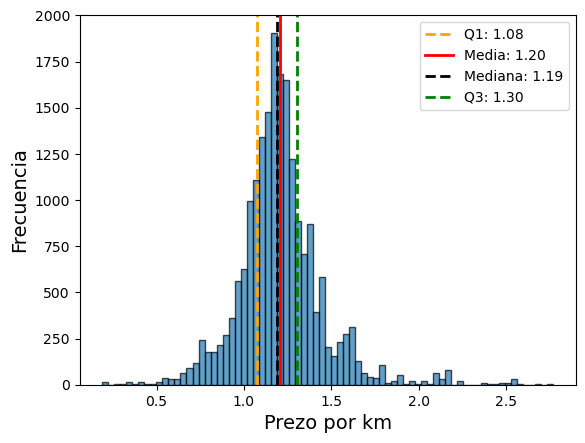

In [19]:

q25 = np.quantile(datos['cl_price_km'], 0.25)
q75 = np.quantile(datos['cl_price_km'], 0.75)
mean = np.mean(datos['cl_price_km'])
median = np.median(datos['cl_price_km'])
# Regra de Freedman-Diaconis para o número de caixas
h = 2*(q75-q25)/datos.shape[0]**(1/3)
bins = int(np.ceil((datos['cl_price_km'].max() - datos['cl_price_km'].min()) / h))
plt.hist(datos['cl_price_km'], bins=75, edgecolor='black', alpha=0.7)
plt.xlabel("Prezo por km", fontsize = 14)
plt.ylabel("Frecuencia", fontsize = 14)
plt.axvline(q25, color='orange', linestyle='--', linewidth=2, label=f'Q1: {q25:.2f}')
plt.axvline(mean, color='red', linestyle='-', linewidth=2, label=f'Media: {mean:.2f}')
plt.axvline(median, color='black', linestyle='--', linewidth=2, label=f'Mediana: {median:.2f}')
plt.axvline(q75, color='green', linestyle='--', linewidth=2, label=f'Q3: {q75:.2f}')
plt.legend()
plt.show()


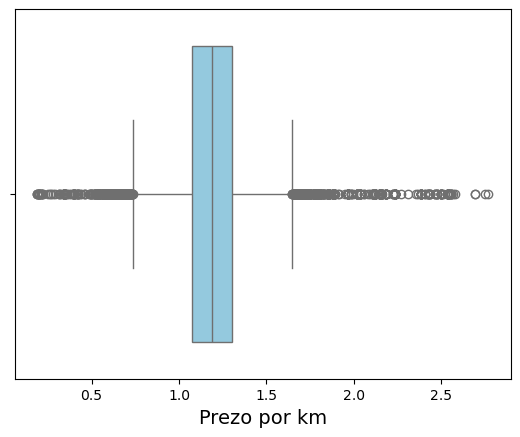

In [20]:
sns.boxplot(x=datos['cl_price_km'], color="skyblue")
plt.xlabel("Prezo por km", fontsize = 14)
plt.show()


Agora para os proveedores:

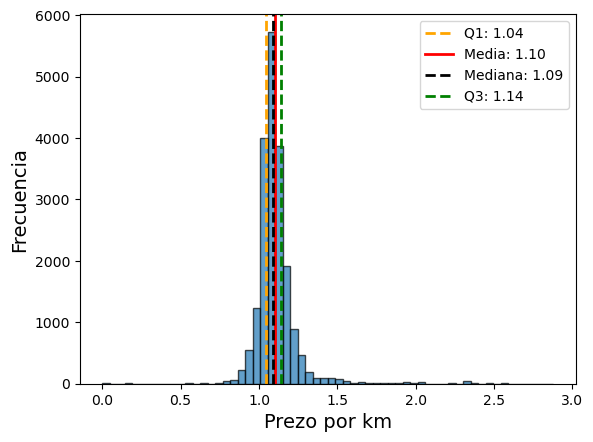

In [21]:
q25 = np.quantile(datos['pro_price_km'], 0.25)
q75 = np.quantile(datos['pro_price_km'], 0.75)
mean = np.mean(datos['pro_price_km'])
median = np.median(datos['pro_price_km'])
# Regra de Freedman-Diaconis para o número de caixas
h = 2*(q75-q25)/datos.shape[0]**(1/3)
bins = int(np.ceil((datos['pro_price_km'].max() - datos['pro_price_km'].min()) / h))
plt.hist(datos['pro_price_km'], bins=60, edgecolor='black', alpha=0.7)
plt.xlabel("Prezo por km", fontsize = 14)
plt.ylabel("Frecuencia", fontsize = 14)
plt.axvline(q25, color='orange', linestyle='--', linewidth=2, label=f'Q1: {q25:.2f}')
plt.axvline(mean, color='red', linestyle='-', linewidth=2, label=f'Media: {mean:.2f}')
plt.axvline(median, color='black', linestyle='--', linewidth=2, label=f'Mediana: {median:.2f}')
plt.axvline(q75, color='green', linestyle='--', linewidth=2, label=f'Q3: {q75:.2f}')
plt.legend()
plt.show()

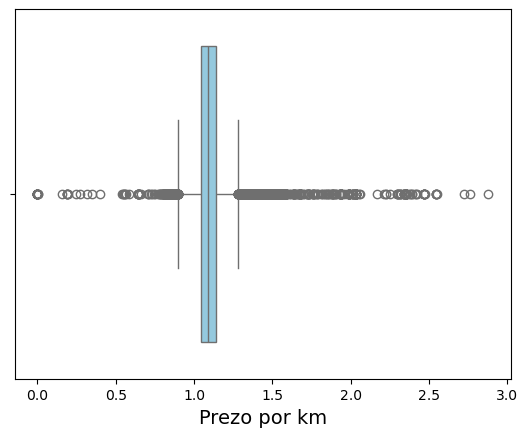

In [22]:
sns.boxplot(x=datos['pro_price_km'], color="skyblue")
plt.xlabel("Prezo por km", fontsize = 14)
plt.show()

### Loaded_km

Imos ver como é a distribución da variable **loaded_km**, que recordemos que son os km que o camión vai con carga. 

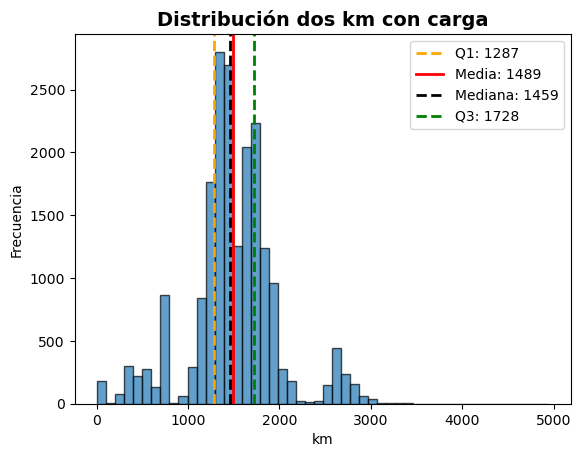

In [23]:
q25 = np.quantile(datos['loaded_km'], 0.25)
q75 = np.quantile(datos['loaded_km'], 0.75)
mean = np.mean(datos['loaded_km'])
median = np.median(datos['loaded_km'])
# Regra de Freedman-Diaconis para o número de caixas
h = 2*(q75-q25)/datos.shape[0]**(1/3)
bins = int(np.ceil((datos['loaded_km'].max() - datos['loaded_km'].min()) / h))
plt.hist(datos['loaded_km'], bins=50, edgecolor='black', alpha=0.7)
plt.title("Distribución dos km con carga", fontdict={'fontsize': 14, 'fontweight': 'bold'})
plt.xlabel("km")
plt.ylabel("Frecuencia")
plt.axvline(q25, color='orange', linestyle='--', linewidth=2, label=f'Q1: {q25:.0f}')
plt.axvline(mean, color='red', linestyle='-', linewidth=2, label=f'Media: {mean:.0f}')
plt.axvline(median, color='black', linestyle='--', linewidth=2, label=f'Mediana: {median:.0f}')
plt.axvline(q75, color='green', linestyle='--', linewidth=2, label=f'Q3: {q75:.0f}')
plt.legend()
plt.show()

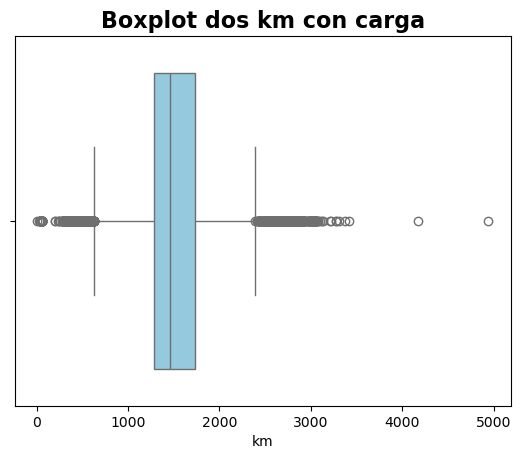

In [24]:
sns.boxplot(x=datos['loaded_km'], color="skyblue")
plt.title("Boxplot dos km con carga", fontdict={'fontsize': 16, 'fontweight': 'bold'})
plt.xlabel("km")
plt.show()

## Relacións entre as variables

Comézase estudando a correlación entre as variables escalares da base de datos. Sinálese que, por construción, pódese intuír que algunhas destas variables están altamente correlacionadas (p. e. loded_km e pro_price_loaded).

In [25]:
corr = datos.corr(numeric_only=True, method='pearson')
corr = corr.drop(index="festivo", columns="festivo")
corr

,client_price,empty_km,loaded_km,po_price_empty,po_price_loaded,total_km,pro_price,cl_price_km,pro_price_km
client_price,1.000000,0.150050,0.910741,0.160560,0.916635,0.843500,0.877904,0.212282,0.179749
empty_km,0.150050,1.000000,0.163807,0.974752,0.131461,0.524549,0.436849,-0.478857,-0.185538
loaded_km,0.910741,0.163807,1.000000,0.165987,0.943681,0.925805,0.904033,-0.088481,0.006517
po_price_empty,0.160560,0.974752,0.165987,1.000000,0.139905,0.516756,0.452701,-0.458825,-0.134690
po_price_loaded,0.916635,0.131461,0.943681,0.139905,1.000000,0.864805,0.946228,0.042718,0.315231
total_km,0.843500,0.524549,0.925805,0.516756,0.864805,1.000000,0.947605,-0.259850,-0.065470
pro_price,0.877904,0.436849,0.904033,0.452701,0.946228,0.947605,1.000000,-0.111437,0.239866
cl_price_km,0.212282,-0.478857,-0.088481,-0.458825,0.042718,-0.259850,-0.111437,1.000000,0.488532
pro_price_km,0.179749,-0.185538,0.006517,-0.134690,0.315231,-0.065470,0.239866,0.488532,1.000000


Graficamente:

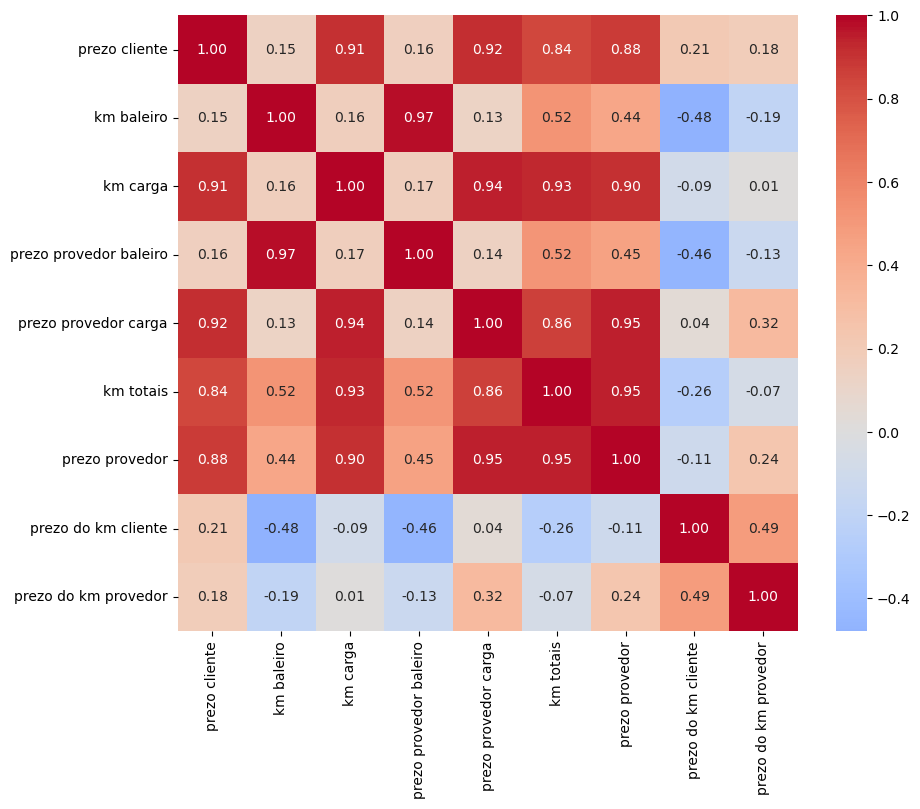

In [26]:
plt.figure(figsize=(10, 8))
nomes_grafico = ['prezo cliente', 'km baleiro', 'km carga', 'prezo provedor baleiro',
                 'prezo provedor carga', 'km totais', 'prezo provedor', 'prezo do km cliente',
                 'prezo do km provedor']

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,  
            xticklabels = nomes_grafico,
          yticklabels = nomes_grafico)

plt.show()

## Cluster dos clientes

Comezamos lendo o csv onde temos a información sobre o sector de cada unha das rutas.

In [31]:
datos_cluster = pd.read_csv('TFM_cluster.csv', sep = ',', decimal='.')
del datos_cluster['comment']

Agora debemos unir os dataframes para incluír a información do sector ao dataframe onde temos as nosas variables:

In [32]:
datos_com = datos.merge(datos_cluster, on='lane_zipcode', how='left')
datos_com['sector'] = datos_com['sector'].astype('category')
datos_com['sector'] = datos_com['sector'].cat.rename_categories({'fruta': 'froita'})
datos_com['sector'].cat.categories

Index(['alimentacion', 'electrónica', 'froita', 'industria', 'paqueteria',
       'retail', 'transporte'],
      dtype='object')

Farase o clustering coa información das variables sector e contrato, ambas categgóricas. Por conseguinte, previamente lévase a cabo unha análise de correspondencias.

### Análise de correspondencias

In [33]:
tabla = pd.crosstab(datos_com['sector'], datos_com['contract'])
print(tabla)

contract       fix  spot
sector                  
alimentacion  1063   111
electrónica    781   490
froita         572     2
industria     1173   188
paqueteria    9535   211
retail        1878  1661
transporte    1233   971


Para comezar, débese facer un test de independencia. A CA baseáse en estudar a relación entre dúas variables categóricas, se non existe relación (independencia) non ten sentido facer dita análise. Emprégase o test ji-cadrado:

In [34]:
chi2, p, dof, expected = chi2_contingency(tabla)
print(f"Estadístico chi-cuadrado: {chi2:.3f}")
print(f"Grados de libertade: {dof}")
print(f"Valor p: {p:.5f}")


Estadístico chi-cuadrado: 5170.131
Grados de libertade: 6
Valor p: 0.00000


Rexéitas claramente a independencia das variables.

In [35]:
# Crear modelo de CA
ca = prince.CA(
    n_components=1,   # Número de dimensions factoriais a reter, o CA sempre obtén como
                      # máximo min(I-1,J-1) variables (neste caso será 1)     
    n_iter=10,   # nº de iteracións internas  
    copy=True, # fai unha copia do dataframe
    check_input=True, # comproba validez dos datos de entrada
    engine='sklearn', # librería interna que fai os cálculos
    random_state=2810 # semente por si é preciso
)
ca = ca.fit(tabla)
row_coords = ca.row_coordinates(tabla)
col_coords = ca.column_coordinates(tabla)
print("\nCoordenadas de las filas:")
print(row_coords)
print("\nCoordenadas de las columnas:")
print(col_coords)



Coordenadas de las filas:
                     0
sector                
alimentacion -0.228539
electrónica   0.524144
froita       -0.464101
industria    -0.115795
paqueteria   -0.417111
retail        0.740963
transporte    0.666519

Coordenadas de las columnas:
                 0
contract          
fix      -0.241340
spot      1.078193


Represéntanse os \textit{scores} graficamente:

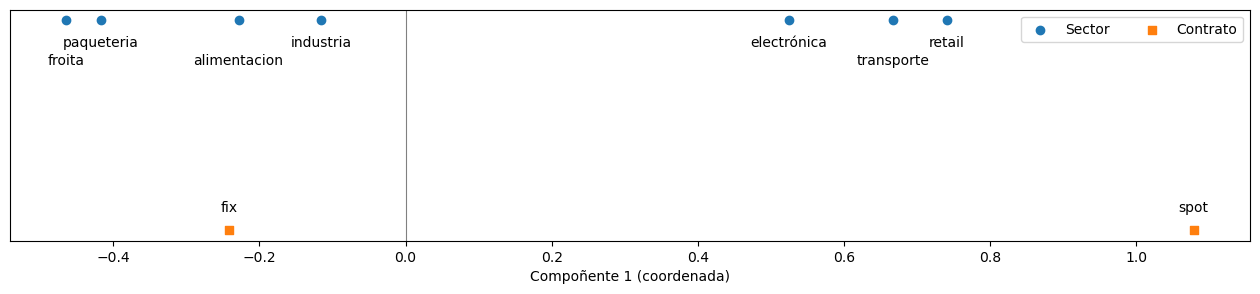

In [36]:
x_rows = row_coords.iloc[:, 0]
x_cols = col_coords.iloc[:, 0]
plt.figure(figsize=(16,3))
y_rows = [1]* len(x_rows)   
y_cols = [-0.15] * len(x_cols)
plt.scatter(x_rows, y_rows, marker='o', label='Sector', zorder=3)
plt.scatter(x_cols, y_cols, marker='s', label='Contrato', zorder=3)
vertical_offset_rows = 0.16 
vertical_offset_cols = 0.16 

for i, txt in enumerate(row_coords.index):
    # Condición para mover etiquetas específicas cara abaixo
    y_adjust = y_rows[i] - vertical_offset_rows # Posición base
    
    if txt in ['froita', 'alimentacion', 'transporte']: 
        y_adjust -= 0.1 # Mover estas 0.1 unidades máis abaixo
    plt.text(x_rows.iloc[i], y_adjust, txt, ha='center', va='bottom', fontsize=10)
for i, txt in enumerate(col_coords.index):
    plt.text(x_cols.iloc[i], y_cols[i] + vertical_offset_cols, txt, ha='center', va='top', fontsize=10)
plt.axvline(0, color='grey', lw=0.8)
plt.yticks([])
plt.xlabel('Compoñente 1 (coordenada)')
plt.title('',
          fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.legend(ncol=2)
plt.show()


### Clustering:

Empréganse os scores como matriz de distancias. Empregarase un algoritmo aglomerativo co método do máximo:

In [37]:
# Estandarizar coordenadas
X = row_coords
# clusters aglomerativos co método do máximo
Z = linkage(X, method='complete')
# Cortar o dendrograma para formar K = 3 clusters
K_opt = 3  
labels_h = fcluster(Z, K_opt, criterion='maxclust')
row_coords["Cluster"] = labels_h
print(row_coords)

                     0  Cluster
sector                         
alimentacion -0.228539        3
electrónica   0.524144        1
froita       -0.464101        2
industria    -0.115795        3
paqueteria   -0.417111        2
retail        0.740963        1
transporte    0.666519        1


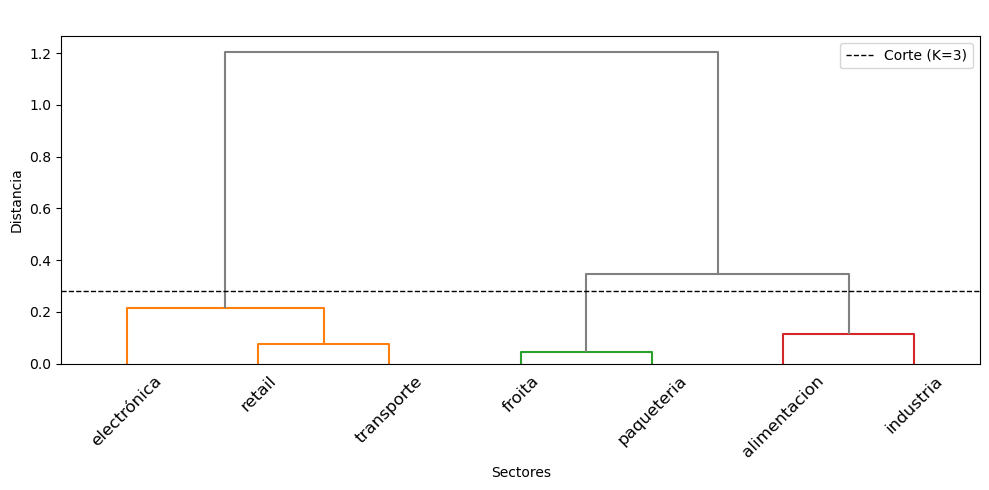

In [38]:
# K clusters
K_objetivo = 3

# 1. Calculamos a altura exacta para cortar en K grupos
# Miramos a distancia de fusión do paso anterior e do actual e collemos a metade
# Z[-(K-1), 2] é a altura onde se fusionan para quedar K-1 grupos
# Z[-K, 2] é a altura onde se fusionan para quedar K grupos
corte_para_color = (Z[-(K_objetivo-1), 2] + Z[-K_objetivo, 2]) / 2
plt.figure(figsize=(10, 5))
# 2. Xeramos o dendrograma usando 'color_threshold'
dendrogram(
    Z, 
    labels=row_coords.index, 
    leaf_rotation=45,      # Rotación a 45º
    color_threshold=corte_para_color, 
    above_threshold_color='grey' 
)

plt.axhline(y=corte_para_color, c='black', lw=1, linestyle='--', 
            label=f'Corte (K={K_objetivo})')
plt.title(f' ', fontdict={'fontsize': 16, 'fontweight': 'bold'})
plt.xlabel('Sectores')
plt.ylabel('Distancia')
plt.legend()
plt.tight_layout()
plt.show()

Fórmanse 3 clusters: un formado polos clientes dos sectores $\textit{retail}$, transporte e electrónica. O segundo formado polos clientes de paquetería e froita, e o último formado polos sectores de alimentación e industria.

Engádese a información aos datos orixinais:

In [39]:
row_coords = row_coords.reset_index()  
datos = datos_com.merge(
    row_coords[["sector", "Cluster"]],
    on="sector",
    how="left"   
)

Proporción de datos por clúster:

In [40]:
print(datos['Cluster'].value_counts().sort_index())
vc = datos['Cluster'].value_counts().sort_index()
print(vc/datos.shape[0])

Cluster
1     7014
2    10320
3     2535
Name: count, dtype: int64
Cluster
1    0.353012
2    0.519402
3    0.127586
Name: count, dtype: float64


### Análise descritivo por cluster

Repítese a análise por clúster:

**Prezos por kilómetro**

Clientes:

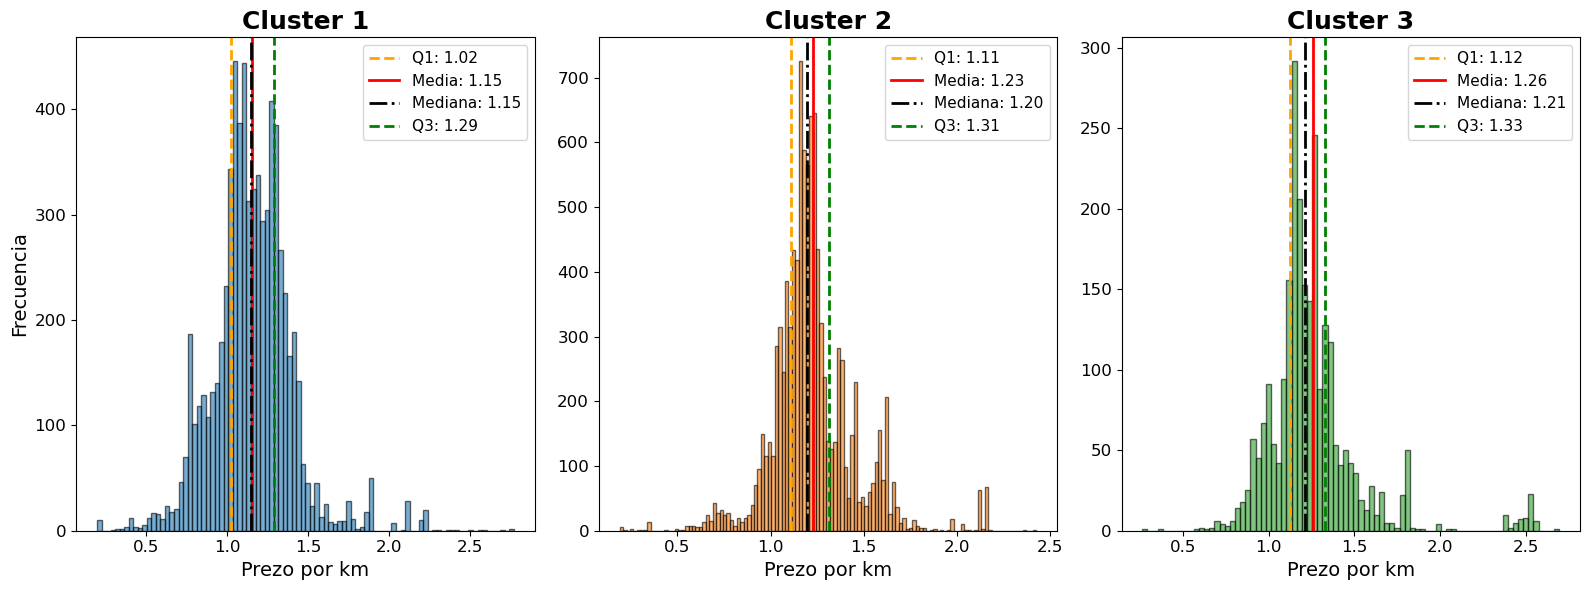

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False) 
colors = ['tab:blue', 'tab:orange', 'tab:green']
clusters = sorted(datos['Cluster'].unique())
for ax, cluster_id, color in zip(axes, clusters, colors):
    subset = datos[datos['Cluster'] == cluster_id]
    data_col = subset['cl_price_km']
    q25 = np.quantile(data_col, 0.25)
    median = np.median(data_col)
    q75 = np.quantile(data_col, 0.75)
    mean = np.mean(data_col)
    iqr = q75 - q25
    if iqr > 0:
        h = 2 * iqr / (len(data_col) ** (1/3))
        bins = int(np.ceil((data_col.max() - data_col.min()) / h))
    else:
        bins = 20
    ax.hist(data_col, bins=bins, color=color, edgecolor='black', alpha=0.6)
    ax.axvline(q25, color='orange', linestyle='--', linewidth=2, label=f'Q1: {q25:.2f}')
    ax.axvline(mean, color='red', linestyle='-', linewidth=2, label=f'Media: {mean:.2f}')
    ax.axvline(median, color='black', linestyle='-.', linewidth=2, label=f'Mediana: {median:.2f}')
    ax.axvline(q75, color='green', linestyle='--', linewidth=2, label=f'Q3: {q75:.2f}')
    ax.set_title(f"Cluster {cluster_id}", fontsize=18, fontweight='bold') 
    ax.set_xlabel("Prezo por km", fontsize=14) 
    if cluster_id == clusters[0]:
        ax.set_ylabel("Frecuencia", fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12) 
    ax.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.show()

/var/folders/72/92sdss296tdg9zgnwr3xcg180000gn/T/ipykernel_6419/2245407225.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


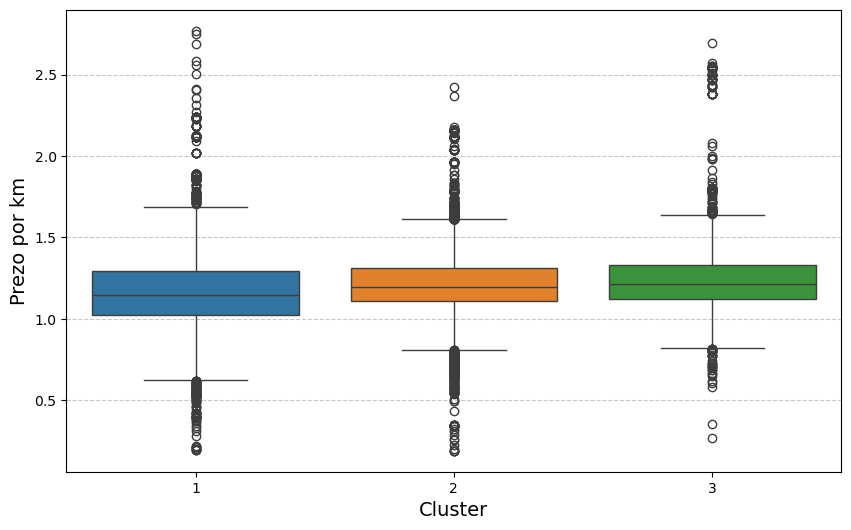

In [42]:
plt.figure(figsize=(10, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']
sns.boxplot(
    x='Cluster', 
    y='cl_price_km', 
    data=datos, 
    palette=colors 
)
plt.xlabel('Cluster', fontsize = 14)
plt.ylabel('Prezo por km', fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Proveedores:

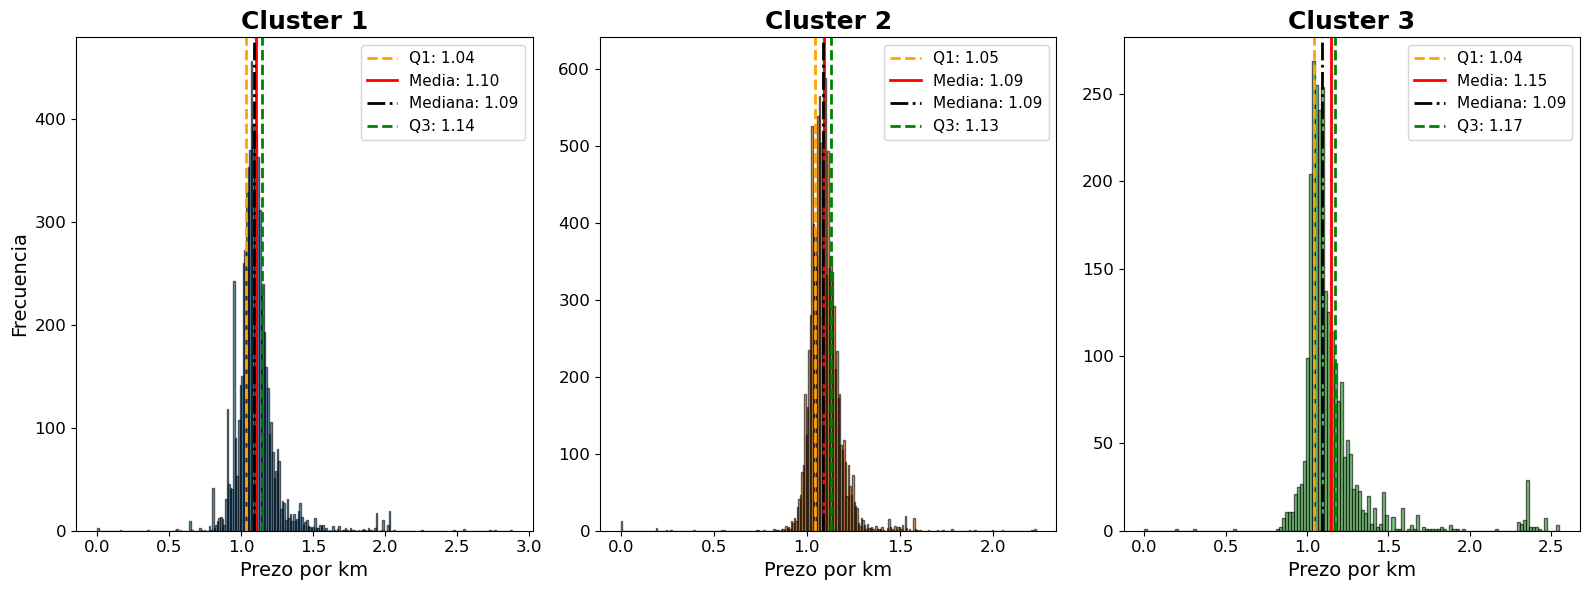

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)
colors = ['tab:blue', 'tab:orange', 'tab:green']
clusters = sorted(datos['Cluster'].unique()) 
for ax, cluster_id, color in zip(axes, clusters, colors):
    subset = datos[datos['Cluster'] == cluster_id]
    data_col = subset['pro_price_km']
    q25 = np.quantile(data_col, 0.25)
    median = np.median(data_col)
    q75 = np.quantile(data_col, 0.75)
    mean = np.mean(data_col)
    iqr = q75 - q25
    if iqr > 0:
        h = 2 * iqr / (len(data_col) ** (1/3))
        bins = int(np.ceil((data_col.max() - data_col.min()) / h))
    else:
        bins = 20 
    ax.hist(data_col, bins=bins, color=color, edgecolor='black', alpha=0.6)
    ax.axvline(q25, color='orange', linestyle='--', linewidth=2, label=f'Q1: {q25:.2f}')
    ax.axvline(mean, color='red', linestyle='-', linewidth=2, label=f'Media: {mean:.2f}')
    ax.axvline(median, color='black', linestyle='-.', linewidth=2, label=f'Mediana: {median:.2f}')
    ax.axvline(q75, color='green', linestyle='--', linewidth=2, label=f'Q3: {q75:.2f}')
    ax.set_title(f"Cluster {cluster_id}", fontsize=18, fontweight='bold')
    ax.set_xlabel("Prezo por km", fontsize=14) 
    
    if cluster_id == clusters[0]:
        ax.set_ylabel("Frecuencia", fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.show()

/var/folders/72/92sdss296tdg9zgnwr3xcg180000gn/T/ipykernel_6419/1296119845.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


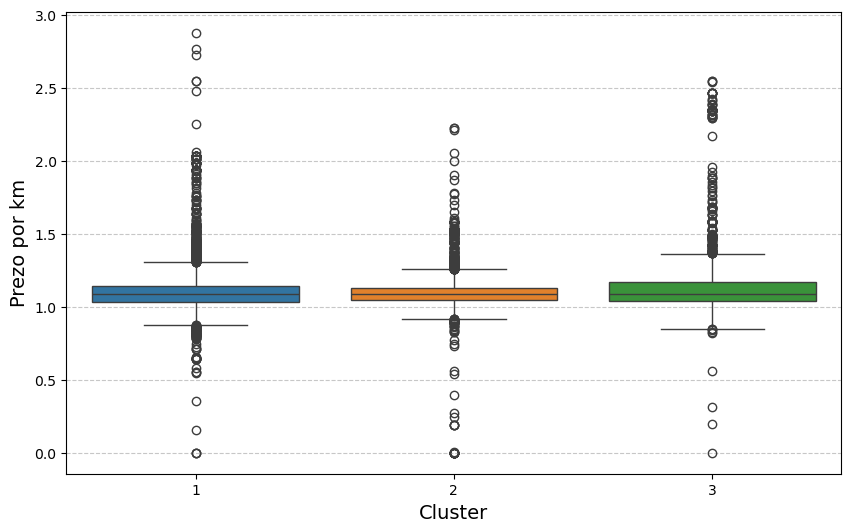

In [44]:
plt.figure(figsize=(10, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']
sns.boxplot(
    x='Cluster', 
    y='pro_price_km', 
    data=datos, 
    palette=colors  
)
plt.xlabel('Cluster', fontsize = 14)
plt.ylabel('Prezo por km', fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Evolución do prezo do km 

Estudo da evolución temporal mensual e diaria dos prezos para provedores e clientes:

In [45]:
prezo_por_mes = datos.groupby('mes')['cl_price_km'].mean().reset_index()

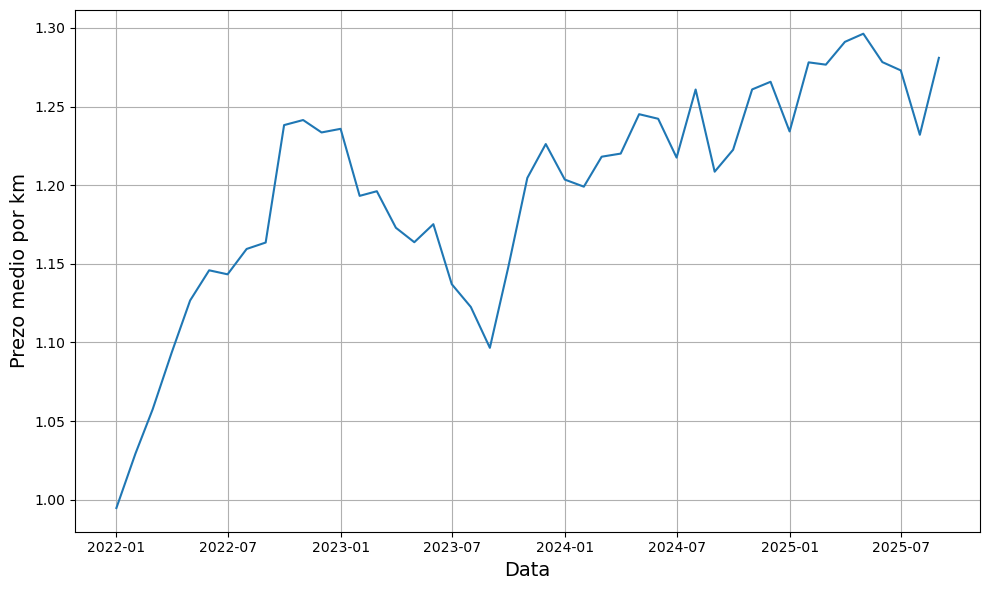

In [46]:
plt.figure(figsize=(10, 6))
plt.plot(prezo_por_mes['mes'], prezo_por_mes['cl_price_km'])
plt.xlabel('Data', fontsize = 14)
plt.ylabel('Prezo medio por km', fontsize = 14)
plt.grid(True)
plt.xticks()
plt.tight_layout()
plt.show()

Proveedores:

In [47]:
pro_prezo_por_mes = datos.groupby('mes')['pro_price_km'].mean().reset_index()

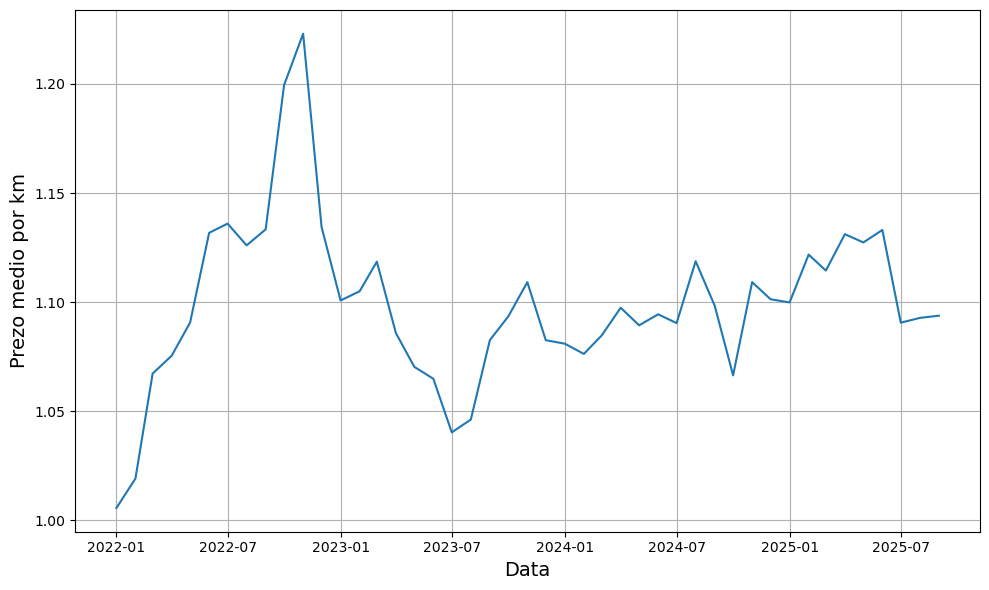

In [48]:
plt.figure(figsize=(10, 6))
plt.plot(pro_prezo_por_mes['mes'], pro_prezo_por_mes['pro_price_km'])
plt.xlabel('Data', fontsize = 14)
plt.ylabel('Prezo medio por km', fontsize = 14)
plt.grid(True)
plt.xticks()
plt.tight_layout()
plt.show()

Aquí vemos mais claro coma nos meses de outubro e novembro de 2022 se alcanzaron prezos moi superiores ao resto dos observados, o cal nos fai pensar que os datos que vimos anteriormente son outliers.

Agora semanalmente verase todavía mellor:

In [49]:
pro_prezo_por_semana = datos.groupby('semana')['pro_price_km'].mean().reset_index()

Comparación prezos clientes vs provedores:

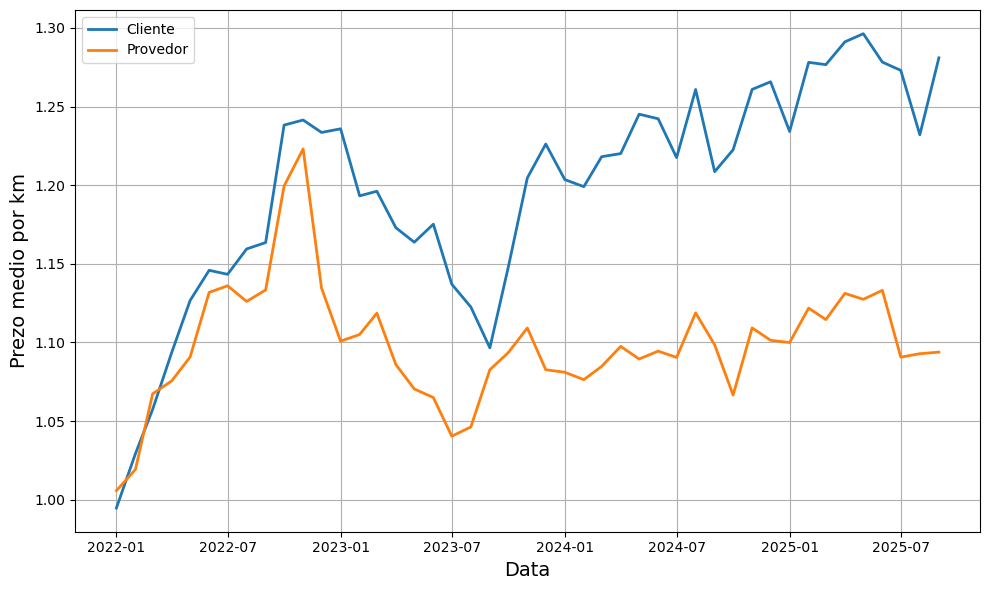

In [50]:
datos_mensuales = datos.groupby('mes')[['cl_price_km', 'pro_price_km']].mean().reset_index()
plt.figure(figsize=(10, 6))
variables_a_pintar = ['cl_price_km', 'pro_price_km']
labels = ['Cliente', 'Provedor']
colors = ['tab:blue', 'tab:orange']
for i, var_name in enumerate(variables_a_pintar):
    plt.plot(datos_mensuales['mes'], datos_mensuales[var_name], 
             color=colors[i], 
             linewidth=2, 
             label=labels[i])
plt.xlabel('Data', fontsize = 14)
plt.ylabel('Prezo medio por km', fontsize = 14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Comparación dia (suavizado):

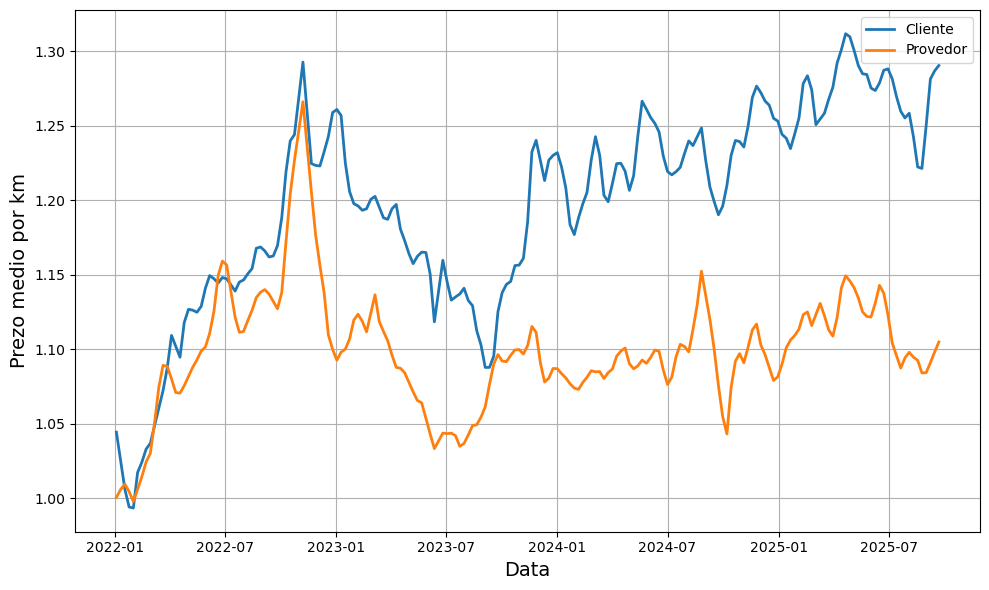

In [51]:
datos_semanal = datos.groupby('semana')[['cl_price_km', 'pro_price_km']].mean().reset_index()
plt.figure(figsize=(10, 6))
variables_a_pintar = ['cl_price_km', 'pro_price_km']
labels = ['Cliente', 'Provedor']
colors = ['tab:blue', 'tab:orange']
for i, var_name in enumerate(variables_a_pintar):
    x_numeric = datos_semanal['semana'].map(pd.Timestamp.toordinal)
    y = datos_semanal[var_name]
    smoothed = lowess(y, x_numeric, frac=0.03, return_sorted=False)
    plt.plot(datos_semanal['semana'], smoothed, 
             color=colors[i], 
             linewidth=2, 
             label=labels[i])
plt.xlabel('Data', fontsize = 14)
plt.ylabel('Prezo medio por km', fontsize = 14)
plt.grid(True)
plt.legend() 
plt.tight_layout()
plt.show()

Clientes:

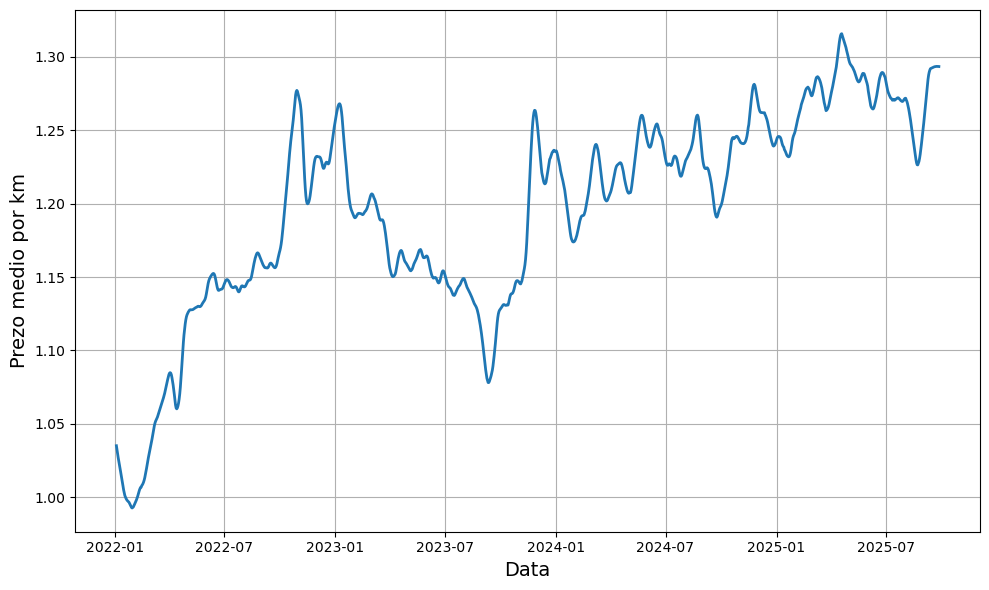

In [52]:
datos_por_dia = datos.groupby('dia')[['cl_price_km', 'pro_price_km']].mean().reset_index()
x = datos_por_dia['dia'].apply(lambda d: d.toordinal())
y = datos_por_dia['cl_price_km']
suavizado = lowess(y, x, frac=0.02)
suavizado_df = pd.DataFrame({
    'dia': [datetime.fromordinal(int(f)) for f in suavizado[:, 0]],
    'cl_price_km_suavizado': suavizado[:, 1]
})
plt.figure(figsize=(10, 6))
# Serie suavizada
plt.plot(suavizado_df['dia'], suavizado_df['cl_price_km_suavizado'], 
         label='LOWESS suavizado', linewidth=2)
plt.xlabel('Data', fontsize = 14)
plt.ylabel('Prezo medio por km', fontsize = 14)
plt.grid(True)
plt.tight_layout()
plt.show()

Provedores:

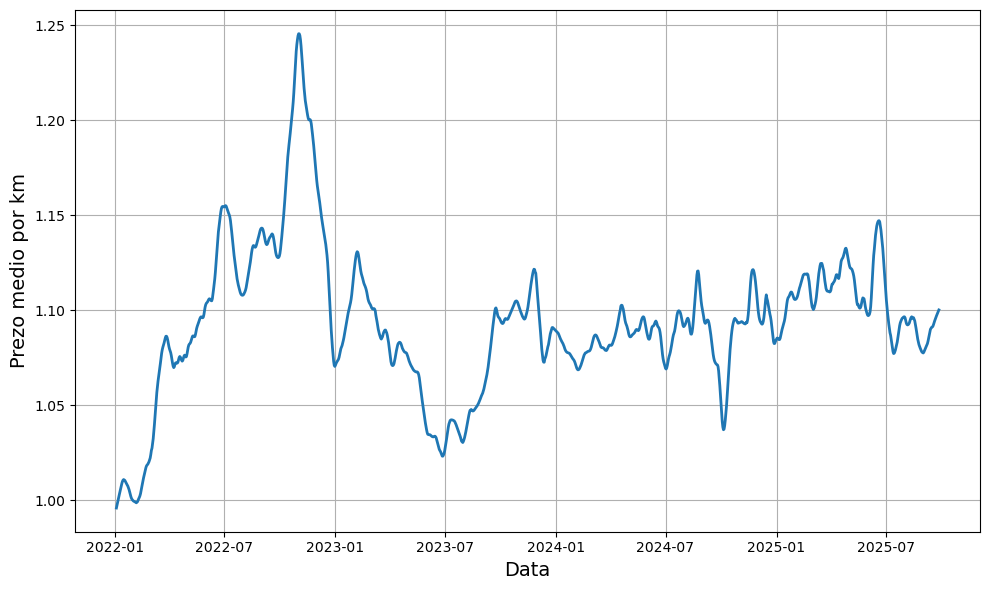

In [53]:
x = datos_por_dia['dia'].apply(lambda d: d.toordinal())
y = datos_por_dia['pro_price_km']
suavizado = lowess(y, x, frac=0.015)
suavizado_df = pd.DataFrame({
    'dia': [datetime.fromordinal(int(f)) for f in suavizado[:, 0]],
    'pro_price_km_suavizado': suavizado[:, 1]
})
plt.figure(figsize=(10, 6))
# Serie suavizada
plt.plot(suavizado_df['dia'], suavizado_df['pro_price_km_suavizado'], label='LOWESS suavizado', linewidth=2)
plt.xlabel('Data', fontsize = 14)
plt.ylabel('Prezo medio por km', fontsize = 14)
plt.grid(True)
plt.tight_layout()
plt.show()


Repítese o estudo por clúster:

Comezamos polos prezos dos clientes:

Nun só gráfico:

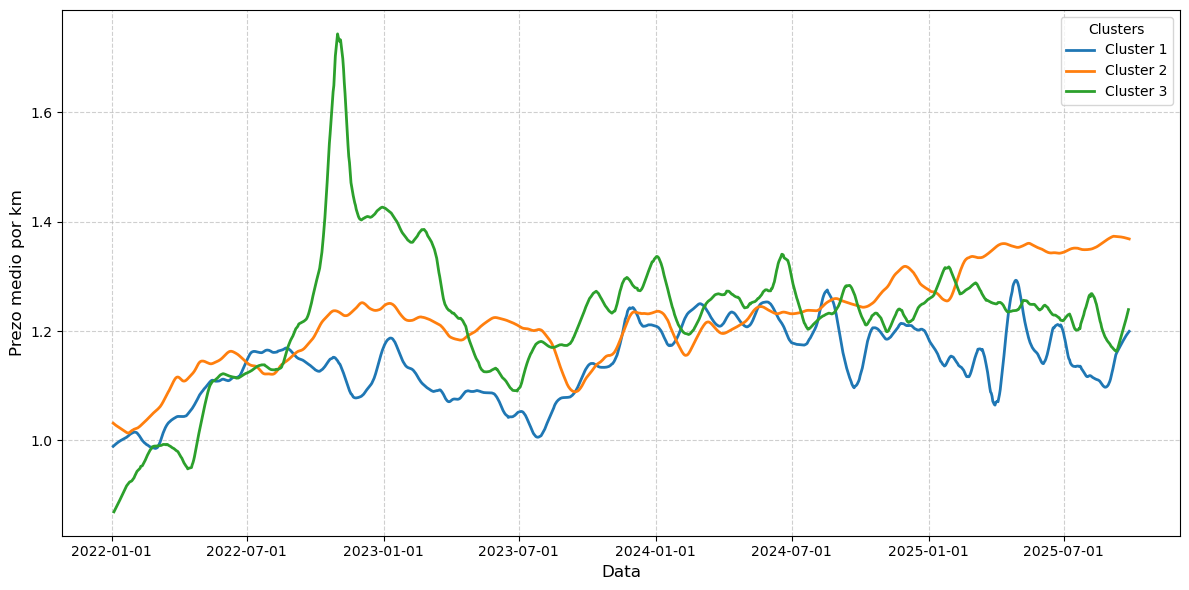

In [73]:
datos['dia'] = pd.to_datetime(datos['dia'])

prezo_por_dia_cluster_cl = (
    datos
    .groupby(['dia', 'Cluster'])['cl_price_km']
    .mean()
    .reset_index()
    .sort_values('dia')
)

plt.figure(figsize=(12, 6))
colors = plt.cm.tab10.colors 
for i, cluster_id in enumerate(sorted(prezo_por_dia_cluster_cl['Cluster'].unique())):
    cluster_data = prezo_por_dia_cluster_cl[prezo_por_dia_cluster_cl['Cluster'] == cluster_id].copy()
    
    x = cluster_data['dia'].apply(lambda x: x.toordinal()).values
    y = cluster_data['cl_price_km'].values
    
    # Aplicar Lowess
    smoothed = nonparametric.lowess(y, x, frac=0.03, return_sorted=False)
    
    plt.plot(cluster_data['dia'], smoothed, color=colors[i], linewidth=2, label=f'Cluster {cluster_id}')

plt.xlabel('Data', fontsize=12)
plt.ylabel('Prezo medio por km', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks()
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Clusters")
plt.tight_layout()
plt.show()

Análogo provedores:

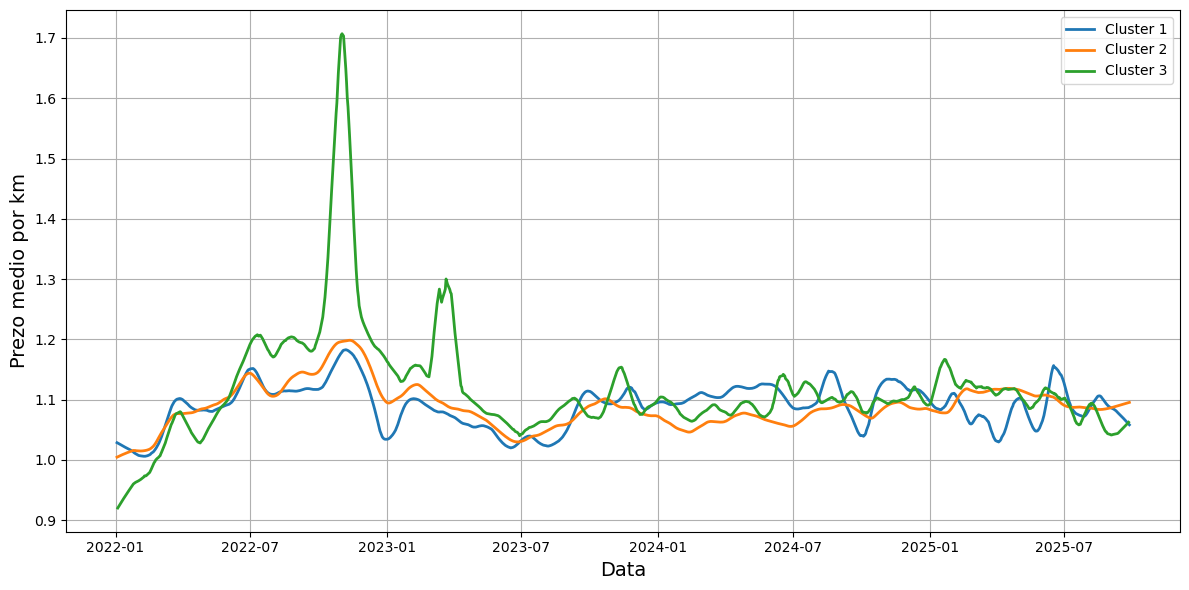

In [ ]:
prezo_por_dia_cluster_pro = (
    datos
    .groupby(['dia', 'Cluster'])['pro_price_km']
    .mean()
    .reset_index()
    .sort_values('dia')
)
plt.figure(figsize=(12, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']  

for i, cluster_id in enumerate(prezo_por_dia_cluster_pro['Cluster'].unique()):
    cluster_data = prezo_por_dia_cluster_pro[prezo_por_dia_cluster_pro['Cluster'] == cluster_id]
    
    x = cluster_data['dia'].map(pd.Timestamp.toordinal)
    y = cluster_data['pro_price_km']
    
    smoothed = lowess(y, x, frac=0.03, return_sorted=False)
    
    plt.plot(cluster_data['dia'], smoothed, color=colors[i], linewidth=2, label=f'Cluster {cluster_id}')

plt.xlabel('Data', fontsize = 14)
plt.ylabel('Prezo medio por km', fontsize = 14)
plt.grid(True)
plt.xticks()
plt.legend()
plt.tight_layout()
plt.show()


Comparación clientes vs provedores por clúster:

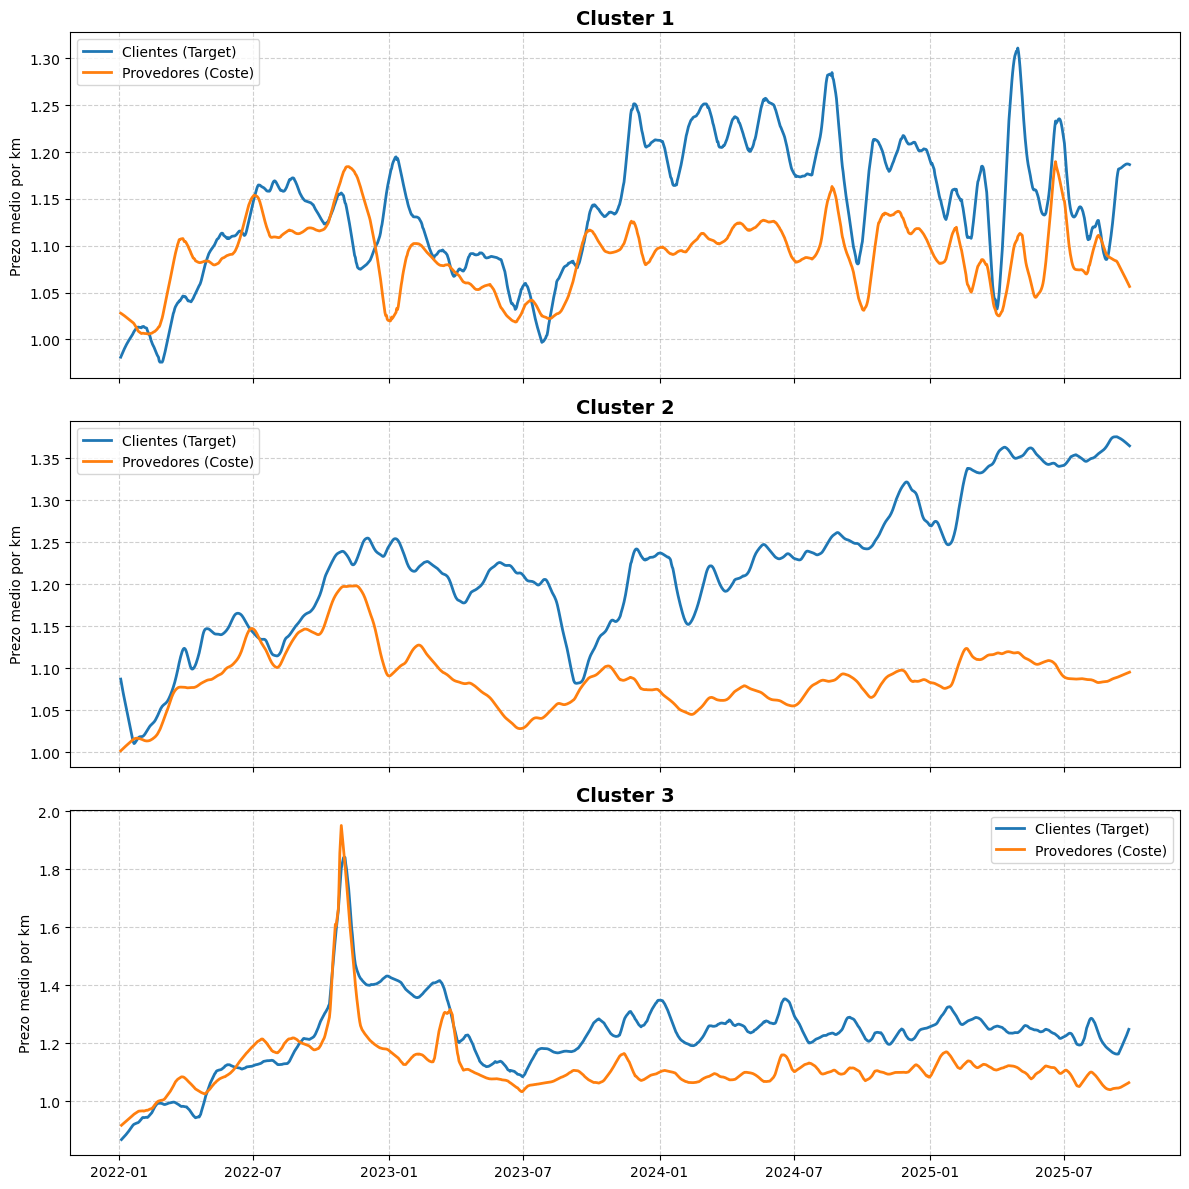

In [75]:
datos['dia'] = pd.to_datetime(datos['dia'])

prezo_por_dia_cluster_comb = (
    datos
    .groupby(['dia', 'Cluster'])[['cl_price_km', 'pro_price_km']] 
    .mean()
    .reset_index()
    .sort_values('dia')
)

prezo_por_dia_cluster_comb['cl_price_km_lowess'] = np.nan
prezo_por_dia_cluster_comb['pro_price_km_lowess'] = np.nan
for cluster_id in prezo_por_dia_cluster_comb['Cluster'].unique():
    mask = prezo_por_dia_cluster_comb['Cluster'] == cluster_id
    cluster_data = prezo_por_dia_cluster_comb[mask]
    x = cluster_data['dia'].apply(lambda t: t.toordinal()).values
    y_cl = cluster_data['cl_price_km'].values
    prezo_por_dia_cluster_comb.loc[mask, 'cl_price_km_lowess'] = nonparametric.lowess(
        y_cl, x, frac=0.025, return_sorted=False
    )
    y_pro = cluster_data['pro_price_km'].values
    prezo_por_dia_cluster_comb.loc[mask, 'pro_price_km_lowess'] = nonparametric.lowess(
        y_pro, x, frac=0.025, return_sorted=False
    )
clusters = sorted(prezo_por_dia_cluster_comb['Cluster'].unique())
fig, axes = plt.subplots(len(clusters), 1, figsize=(12, 4 * len(clusters)), sharex=True)

if len(clusters) == 1:
    axes = [axes]

for i, cluster_id in enumerate(clusters):
    cluster_data = prezo_por_dia_cluster_comb[prezo_por_dia_cluster_comb['Cluster'] == cluster_id]
    
    axes[i].plot(cluster_data['dia'], cluster_data['cl_price_km_lowess'], 
                 label='Clientes (Target)', color='tab:blue', linewidth=2)
    axes[i].plot(cluster_data['dia'], cluster_data['pro_price_km_lowess'], 
                 label='Provedores (Coste)', color='tab:orange', linewidth=2)
    
    axes[i].set_title(f'Cluster {cluster_id}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Prezo medio por km')
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.6)
    
    # Formatear fechas en el eje X
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[i].xaxis.set_major_locator(mdates.AutoDateLocator())

plt.xticks()
plt.tight_layout()
plt.show()

## Evolución temporal do volume de pedidos

Volume mensual de pedidos:

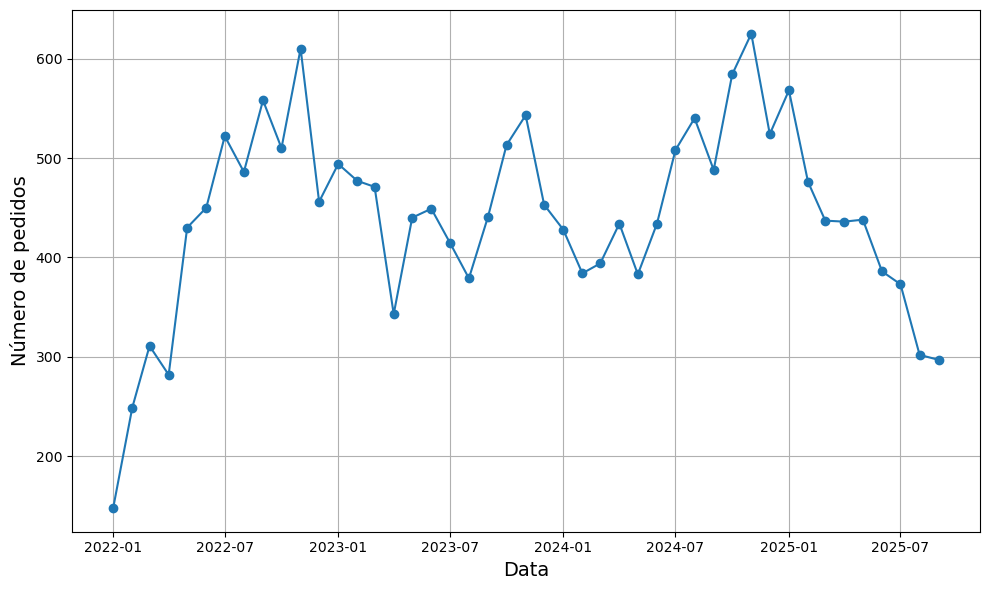

In [68]:
pedidos_por_mes = datos.groupby('mes').size().reset_index(name='n_pedidos')

plt.figure(figsize=(10, 6))
plt.plot(pedidos_por_mes['mes'], pedidos_por_mes['n_pedidos'], marker='o')
plt.xlabel('Data', fontsize = 14)
plt.ylabel('Número de pedidos', fontsize = 14)
plt.grid(True)
plt.xticks()
plt.tight_layout()
plt.show()

Volume semanal:

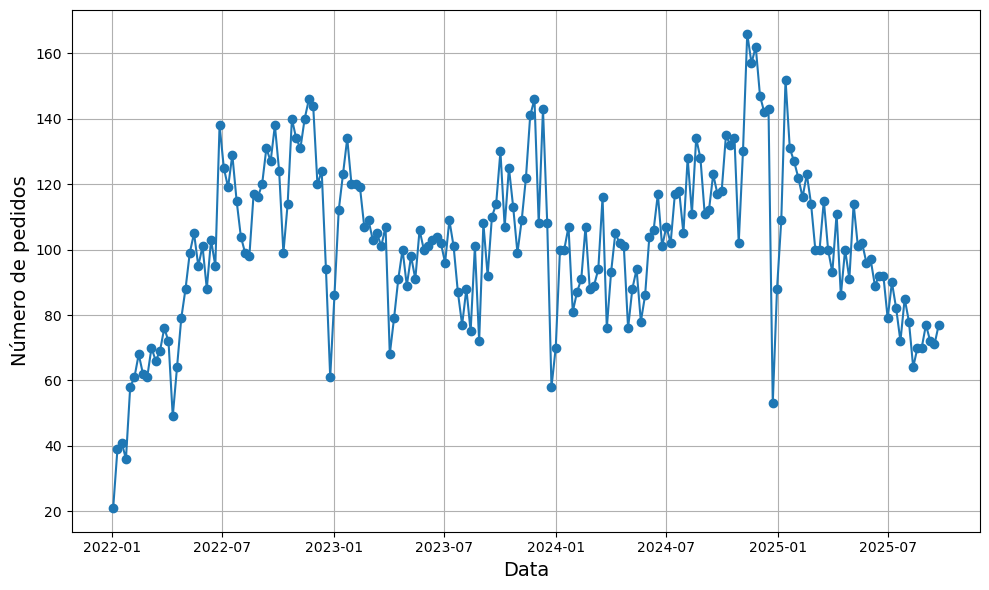

In [69]:
pedidos_por_semana = datos.groupby('semana').size().reset_index(name='n_pedidos')

plt.figure(figsize=(10, 6))
plt.plot(pedidos_por_semana['semana'], pedidos_por_semana['n_pedidos'], marker='o')
plt.xlabel('Data', fontsize = 14)
plt.ylabel('Número de pedidos', fontsize = 14)
plt.grid(True)
plt.xticks()
plt.tight_layout()
plt.show()

Volume semanal por ano:

/var/folders/72/92sdss296tdg9zgnwr3xcg180000gn/T/ipykernel_43776/2959255447.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([nombres_meses[int(x.month)-1] for x in mdates.num2date(plt.gca().get_xticks())])


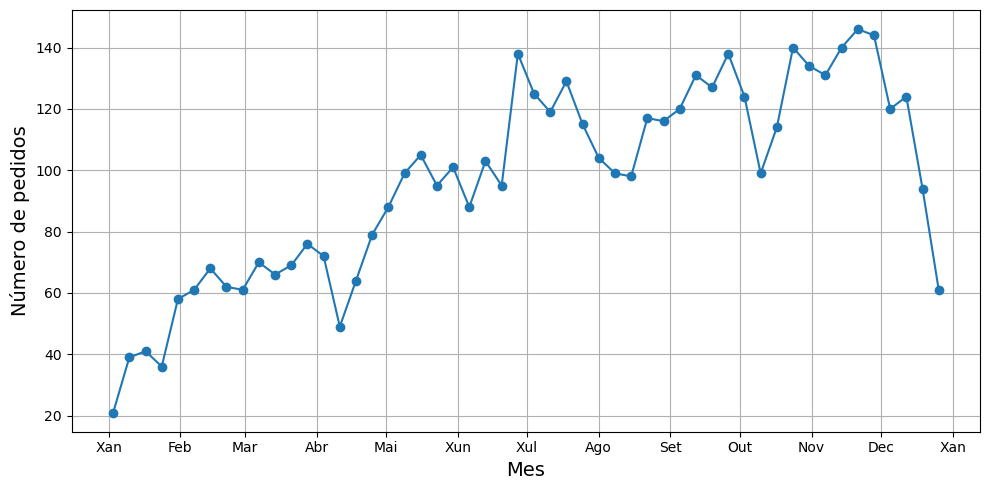

/var/folders/72/92sdss296tdg9zgnwr3xcg180000gn/T/ipykernel_43776/2959255447.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([nombres_meses[int(x.month)-1] for x in mdates.num2date(plt.gca().get_xticks())])


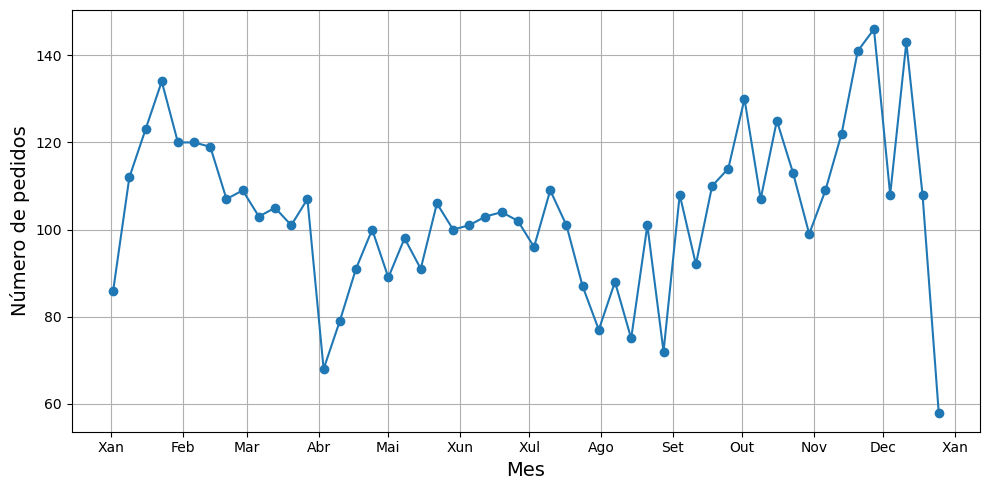

/var/folders/72/92sdss296tdg9zgnwr3xcg180000gn/T/ipykernel_43776/2959255447.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([nombres_meses[int(x.month)-1] for x in mdates.num2date(plt.gca().get_xticks())])


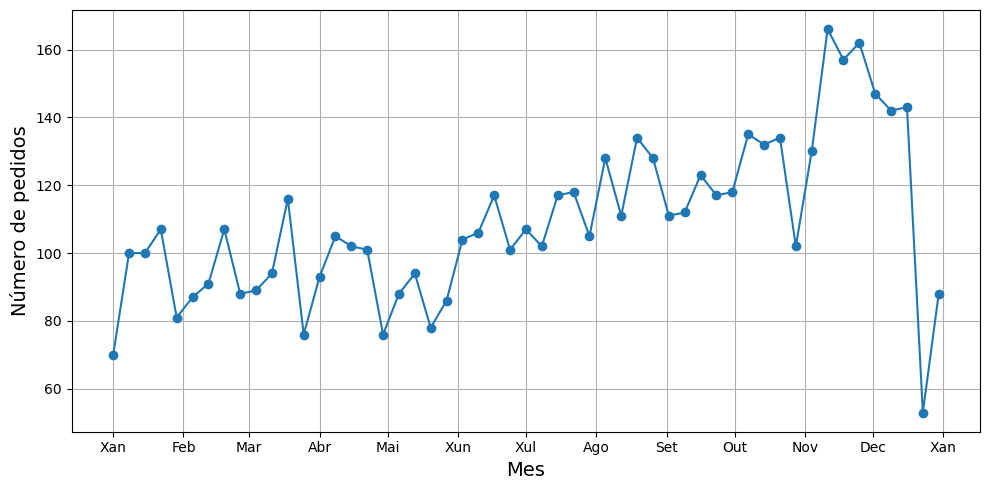

/var/folders/72/92sdss296tdg9zgnwr3xcg180000gn/T/ipykernel_43776/2959255447.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([nombres_meses[int(x.month)-1] for x in mdates.num2date(plt.gca().get_xticks())])


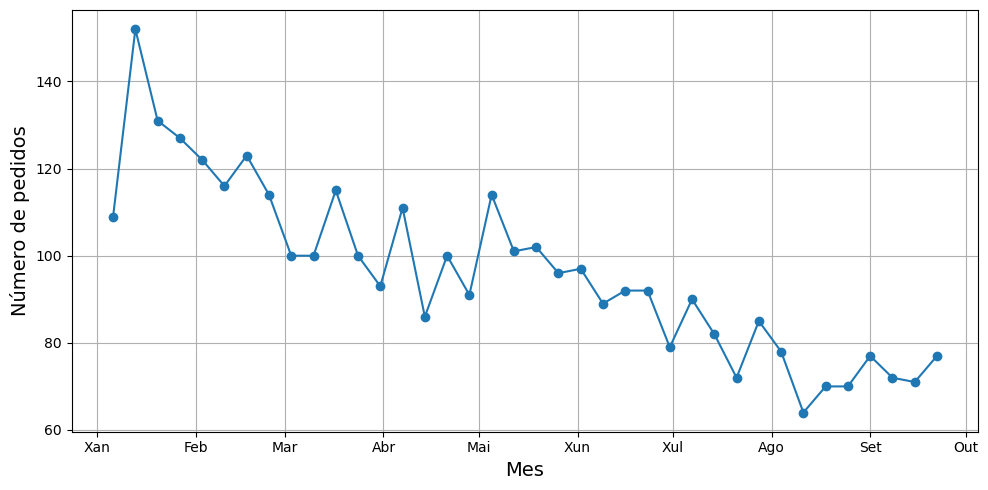

In [ ]:
pedidos_por_semana['semana'] = pd.to_datetime(pedidos_por_semana['semana'])
pedidos_por_semana['ano'] = pedidos_por_semana['semana'].dt.year

# Crear un gráfico por ano
for ano, grupo in pedidos_por_semana.groupby('ano'):
    plt.figure(figsize=(10,5))
    plt.plot(grupo['semana'], grupo['n_pedidos'], marker='o')
    
    plt.xlabel('Mes', fontsize = 14)
    plt.ylabel('Número de pedidos', fontsize = 14)
    
    # Meses en galego:
    nombres_meses = ['Xan', 'Feb', 'Mar', 'Abr', 'Mai', 'Xun', 
                     'Xul', 'Ago', 'Set', 'Out', 'Nov', 'Dec']
    locator = mdates.MonthLocator()
    plt.gca().xaxis.set_major_locator(locator)
    plt.gca().set_xticklabels([nombres_meses[int(x.month)-1] for x in mdates.num2date(plt.gca().get_xticks())])    
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Volume semanal por cluster

Repetimos o estudo do volume de pedidos para cada tipo de cliente por separado:

Comezamos polo estudo mensual.

In [69]:
pedidos_por_mes_cluster = (
    datos
    .groupby(['mes', 'Cluster'])
    .size()
    .reset_index(name='n_pedidos')
)
pedidos_por_semana_cluster = (
    datos
    .groupby(['semana', 'Cluster'])
    .size()
    .reset_index(name='n_pedidos')
)

Por ano e cluster:

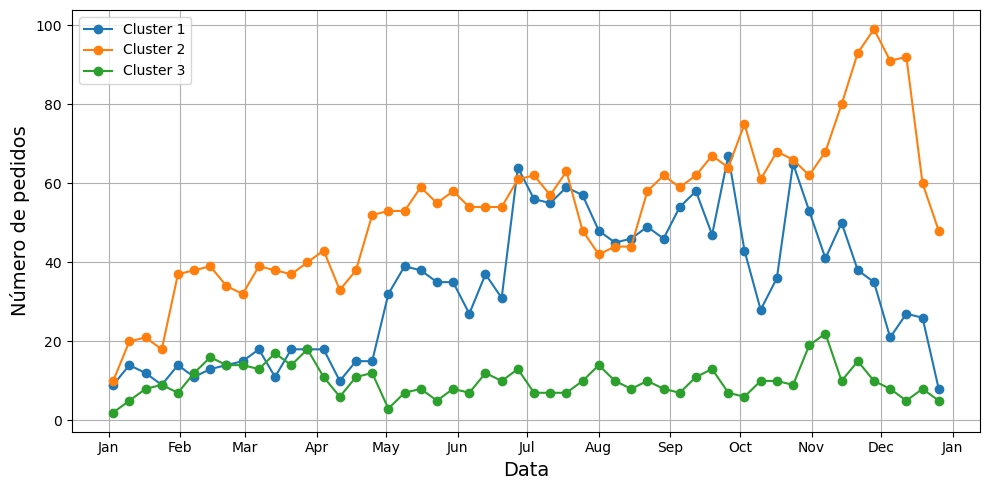

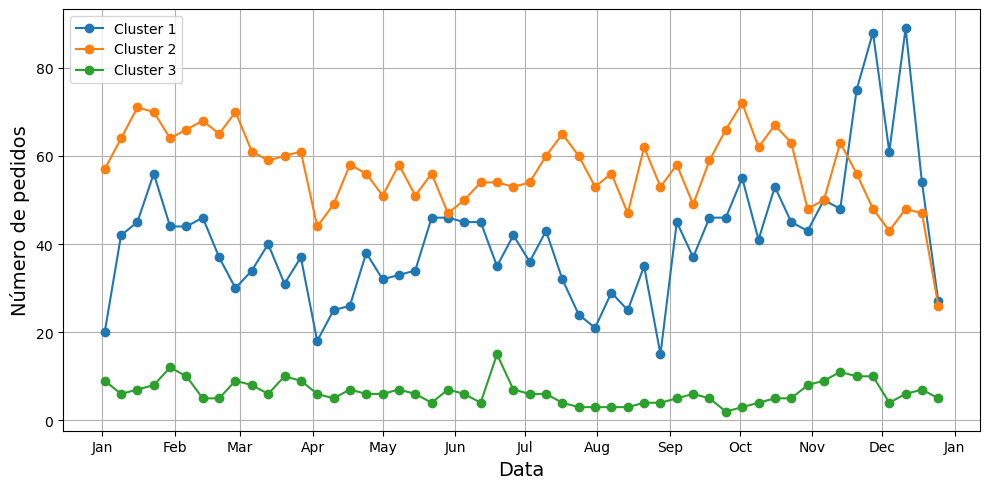

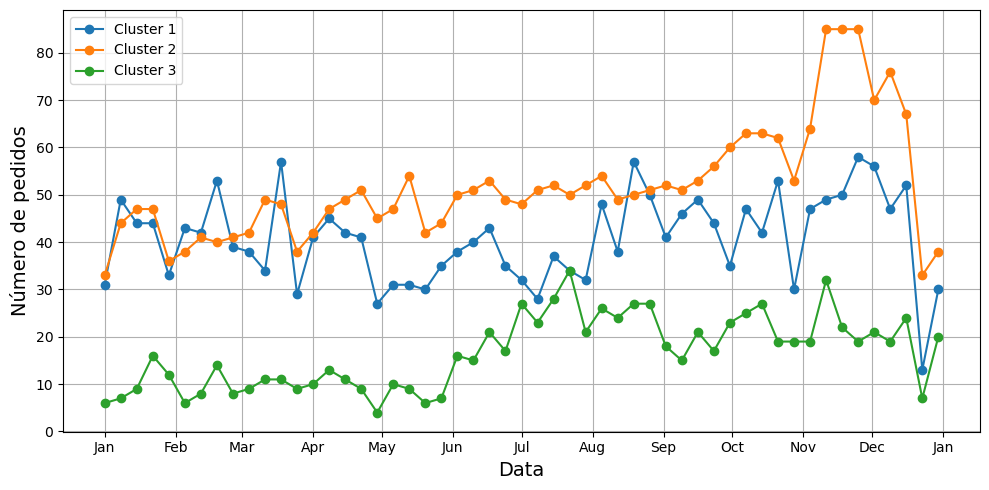

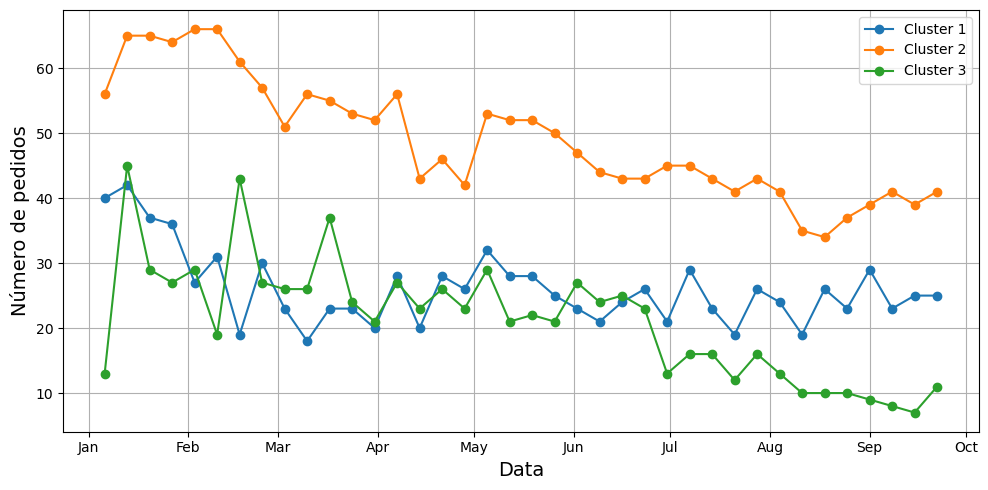

In [ ]:
pedidos_por_semana_cluster['semana'] = pd.to_datetime(pedidos_por_semana_cluster['semana'])
pedidos_por_semana_cluster['ano'] = pedidos_por_semana_cluster['semana'].dt.year
colors = ['tab:blue', 'tab:orange', 'tab:green'] 
for ano, grupo_ano in pedidos_por_semana_cluster.groupby('ano'):
    plt.figure(figsize=(10,5))
    for i, cluster_id in enumerate(grupo_ano['Cluster'].unique()):
        cluster_data = grupo_ano[grupo_ano['Cluster'] == cluster_id]
        plt.plot(
            cluster_data['semana'],
            cluster_data['n_pedidos'],
            marker='o',
            linestyle='-',
            color=colors[i],
            label=f'Cluster {cluster_id}'
        )
    plt.xlabel('Data', fontsize = 14)
    plt.ylabel('Número de pedidos', fontsize = 14)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Efecto dos atípicos

Detección de $\textit{outliers}$ mediante o algoritmo $\textit{Isolation Forest}$:

In [ ]:
iso = IsolationForest(contamination=0.0235, random_state=42)
outliers = iso.fit_predict(datos[['pro_price_km', 'cl_price_km']].values) == -1
np.sum(outliers)/datos.shape[0]*100

Detéctanse daquela un 2.33% de atípicos.

In [78]:
datos['is_outlier'] = outliers
datos_sin_out = datos[datos["is_outlier"] == False].copy()
datos_sin_out.shape


(19406, 26)

Quedan 19406 observacións.

In [79]:
datos_sin_out.describe()

,client_price,empty_km,loaded_km,po_price_empty,po_price_loaded,route_start_date,total_km,pro_price,cl_price_km,pro_price_km,festivo,dia,semana,mes,Cluster
count,19406.000000,19406.000000,19406.000000,19406.000000,19406.000000,19406,19406.000000,19406.000000,19406.000000,19406.000000,19406.000000,19406,19406,19406,19406.000000
mean,1937.091174,149.501597,1498.916778,139.517376,1662.298544,2023-11-24 05:03:35.977171968,1648.418376,1801.815920,1.194708,1.093231,0.037875,2023-11-23 16:29:39.408430592,2023-11-21 12:55:52.530145536,2023-11-08 20:23:41.745851904,1.773524
min,110.000000,0.000000,9.000000,0.000000,0.010000,2022-01-03 06:00:00,51.000000,0.010000,0.491187,0.000009,0.000000,2022-01-03 00:00:00,2022-01-03 00:00:00,2022-01-01 00:00:00,1.000000
25%,1600.000000,0.000000,1299.000000,0.000000,1441.680000,2022-12-21 08:52:30,1391.000000,1522.210000,1.076061,1.041542,0.000000,2022-12-21 00:00:00,2022-12-19 00:00:00,2022-12-01 00:00:00,1.000000
50%,1940.000000,79.000000,1468.000000,69.000000,1665.860000,2023-11-22 16:30:00,1617.000000,1791.280000,1.185345,1.086352,0.000000,2023-11-22 00:00:00,2023-11-20 00:00:00,2023-11-01 00:00:00,2.000000
75%,2240.000000,210.000000,1731.000000,202.267500,1915.500000,2024-10-21 07:48:45,1926.000000,2089.082500,1.296413,1.134309,0.000000,2024-10-21 00:00:00,2024-10-21 00:00:00,2024-10-01 00:00:00,2.000000
max,4693.000000,2784.000000,4941.000000,2526.280000,5517.850000,2025-09-27 11:00:00,5428.000000,5785.500000,2.156863,1.577608,1.000000,2025-09-27 00:00:00,2025-09-22 00:00:00,2025-09-01 00:00:00,3.000000
std,632.477484,214.762701,480.840605,200.545025,539.024943,NaN,558.445375,604.832562,0.212439,0.088105,0.190899,NaN,NaN,NaN,0.649565


In [ ]:
prezo_por_dia_cluster2 = (
    datos_sin_out
    .groupby(['dia', 'Cluster'])['cl_price_km']
    .mean()
    .reset_index()
)
prezo_por_dia_cluster2['dia'] = pd.to_datetime(prezo_por_dia_cluster2['dia'])
prezo_por_dia_cluster2['cl_price_km_lowess'] = np.nan

Impacto no prezo dos clientes:

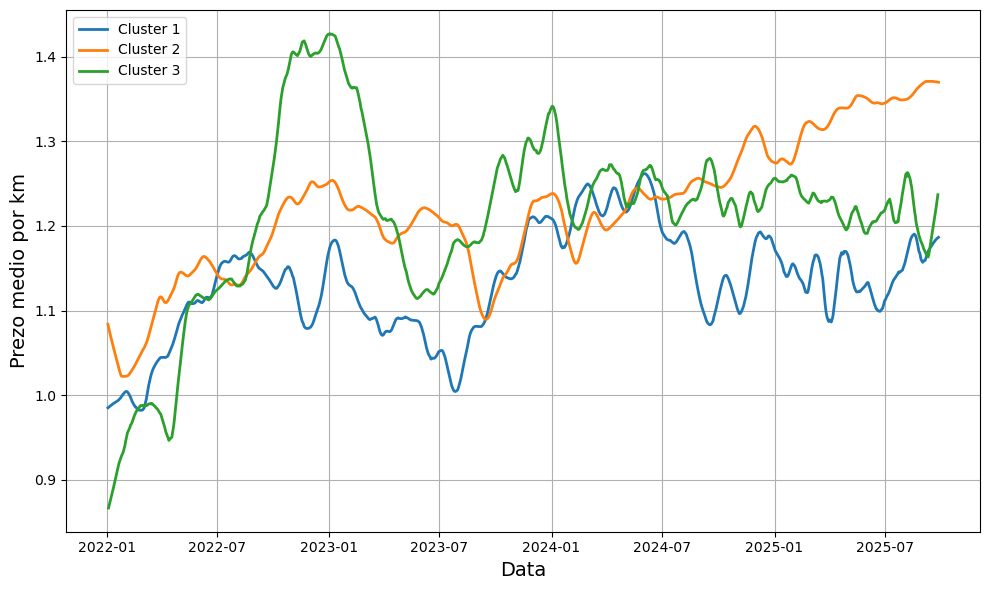

In [83]:
plt.figure(figsize=(10, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']  
for i, cluster_id in enumerate(prezo_por_dia_cluster2['Cluster'].unique()):
    cluster_data = prezo_por_dia_cluster2[prezo_por_dia_cluster2['Cluster'] == cluster_id]
    x = cluster_data['dia'].map(pd.Timestamp.toordinal)
    y = cluster_data['cl_price_km']
    smoothed = lowess(y, x, frac=0.03, return_sorted=False)
    plt.plot(cluster_data['dia'], smoothed, color=colors[i], linewidth=2, 
             label=f'Cluster {cluster_id}')
plt.xlabel('Data', fontsize = 14)
plt.ylabel('Prezo medio por km', fontsize = 14)
plt.grid(True)
plt.xticks()
plt.legend()
plt.tight_layout()
plt.show()


Análogamente para os provedores:

In [84]:
prezo_por_dia_cluster3 = (
    datos_sin_out
    .groupby(['dia', 'Cluster'])['pro_price_km']
    .mean()
    .reset_index()
)

# Asegurarse de que 'dia' sea datetime
prezo_por_dia_cluster3['dia'] = pd.to_datetime(prezo_por_dia_cluster3['dia'])

prezo_por_dia_cluster3['pro_price_km_lowess'] = np.nan


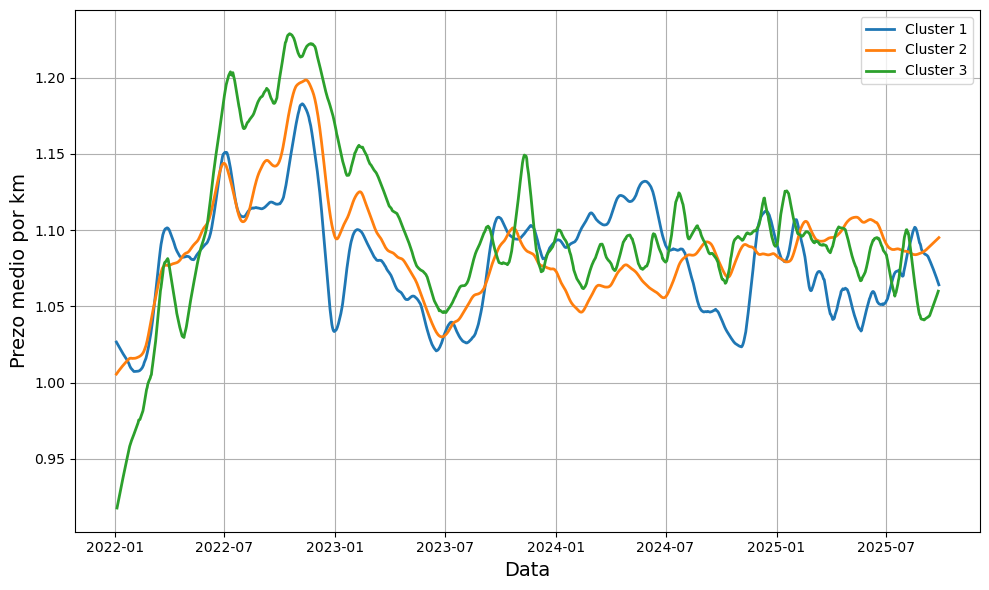

In [86]:
plt.figure(figsize=(10, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']  

for i, cluster_id in enumerate(prezo_por_dia_cluster3['Cluster'].unique()):
    cluster_data = prezo_por_dia_cluster3[prezo_por_dia_cluster3['Cluster'] == cluster_id]
    x = cluster_data['dia'].map(pd.Timestamp.toordinal)
    y = cluster_data['pro_price_km']
    smoothed = lowess(y, x, frac=0.03, return_sorted=False)
    plt.plot(cluster_data['dia'], smoothed, color=colors[i], linewidth=2, 
             label=f'Cluster {cluster_id}')
plt.xlabel('Data', fontsize = 14)
plt.ylabel('Prezo medio por km', fontsize = 14)
plt.grid(True)
plt.xticks()
plt.legend()
plt.tight_layout()
plt.show()


Impacto no volume de envíos por clúster:

In [88]:
pedidos_por_semana_cluster2 = (
    datos_sin_out
    .groupby(['semana', 'Cluster'])
    .size()
    .reset_index(name='n_pedidos')
)

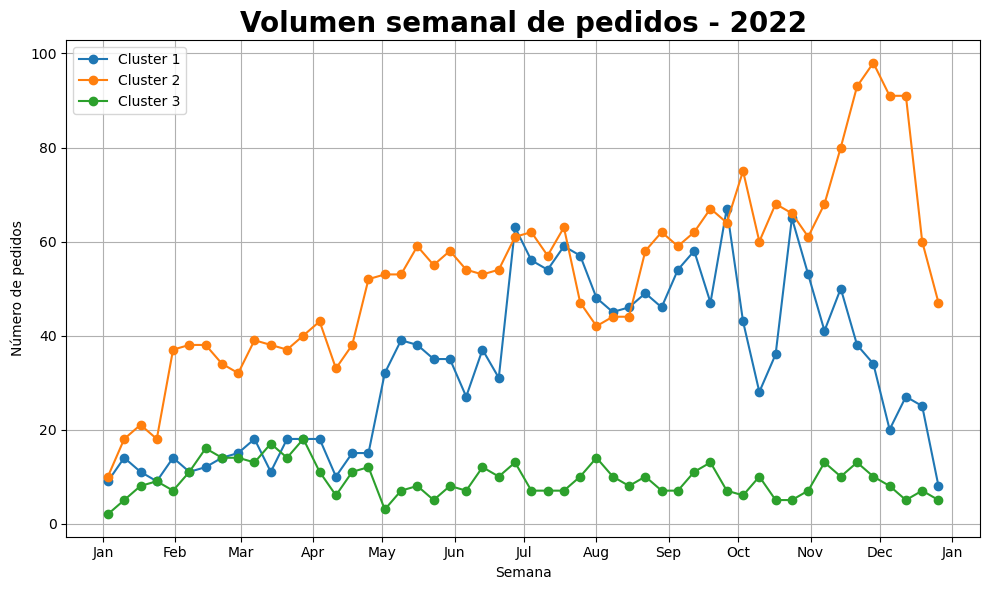

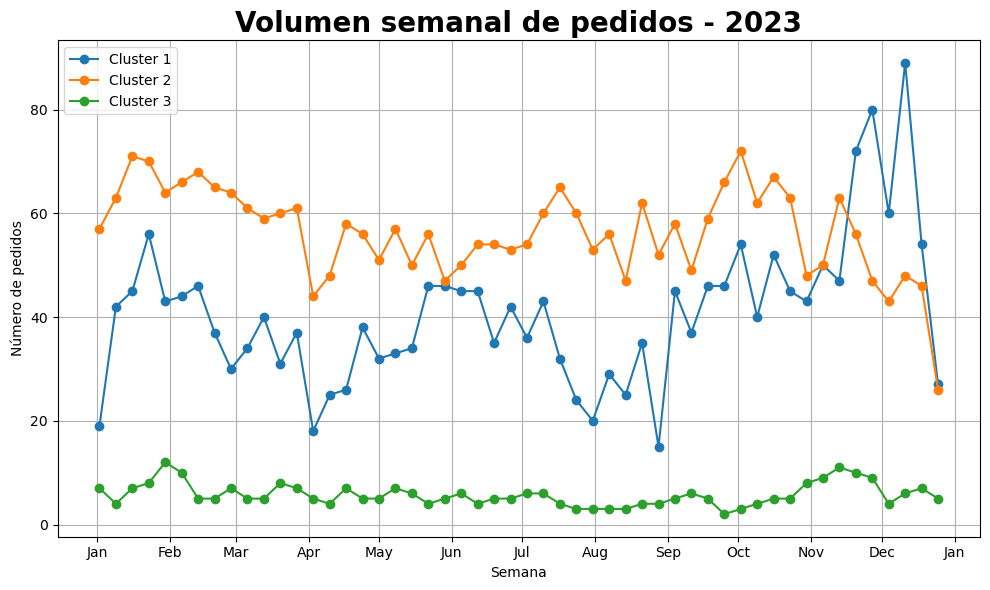

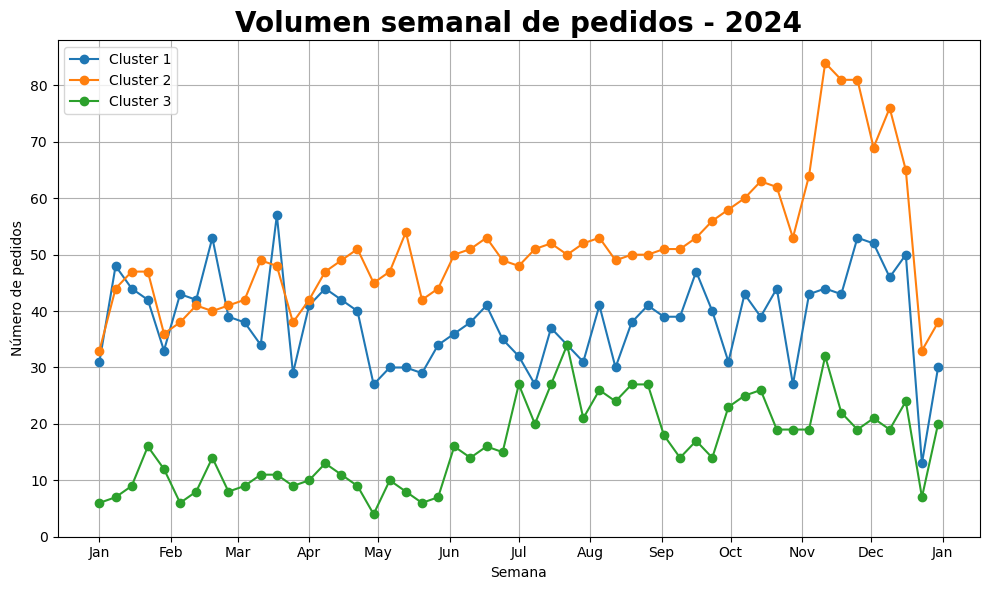

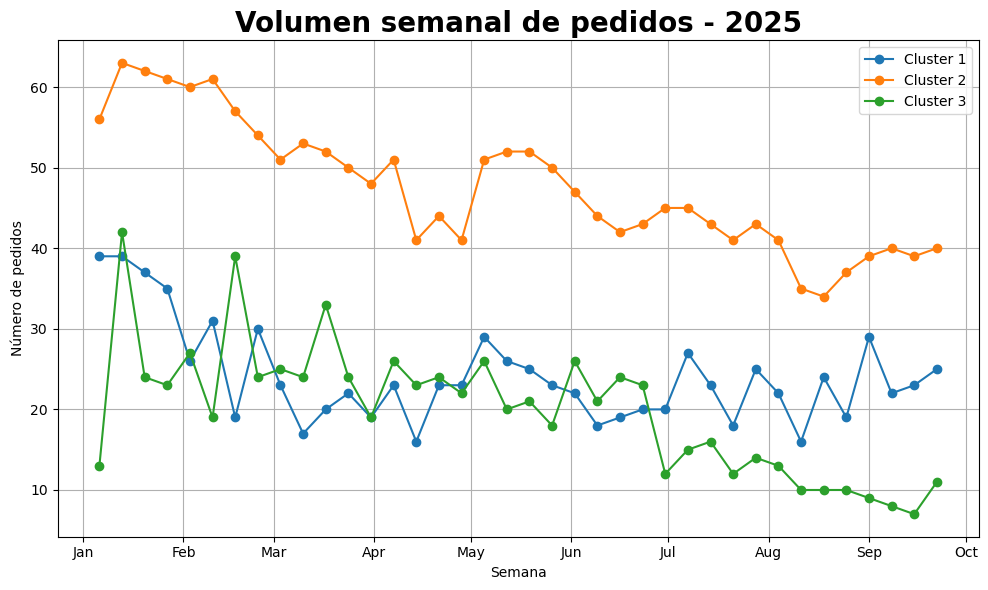

In [89]:
pedidos_por_semana_cluster2['semana'] = pd.to_datetime(pedidos_por_semana_cluster2['semana'])
pedidos_por_semana_cluster2['ano'] = pedidos_por_semana_cluster2['semana'].dt.year
colors = ['tab:blue', 'tab:orange', 'tab:green']  
for ano, grupo_ano in pedidos_por_semana_cluster2.groupby('ano'):
    plt.figure(figsize=(10,6))
    for i, cluster_id in enumerate(grupo_ano['Cluster'].unique()):
        cluster_data = grupo_ano[grupo_ano['Cluster'] == cluster_id]
        plt.plot(
            cluster_data['semana'],
            cluster_data['n_pedidos'],
            marker='o',
            linestyle='-',
            color=colors[i],
            label=f'Cluster {cluster_id}'
        )
    plt.title(f'Volumen semanal de pedidos - {ano}', fontdict={'fontsize': 20, 'fontweight': 'bold'})
    plt.xlabel('Semana')
    plt.ylabel('Número de pedidos')
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

Ou mensualmente e comparando cos datos orixinais:

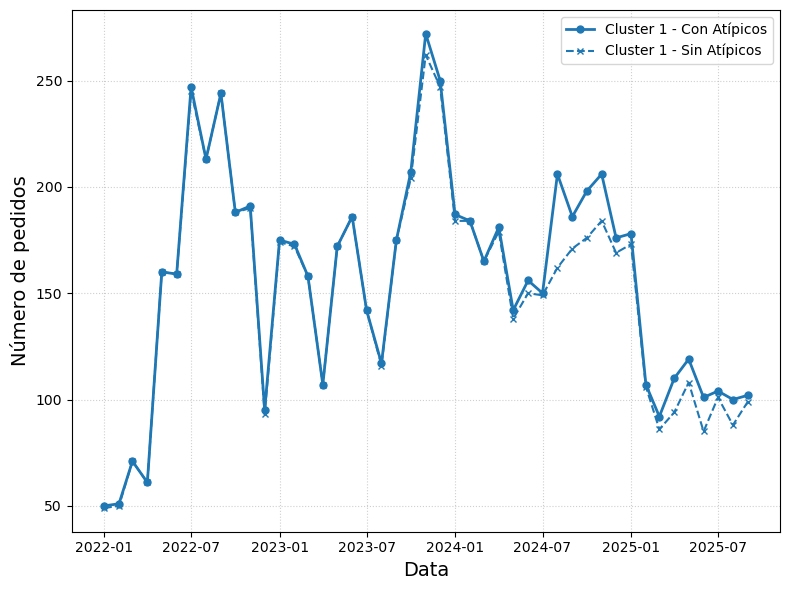

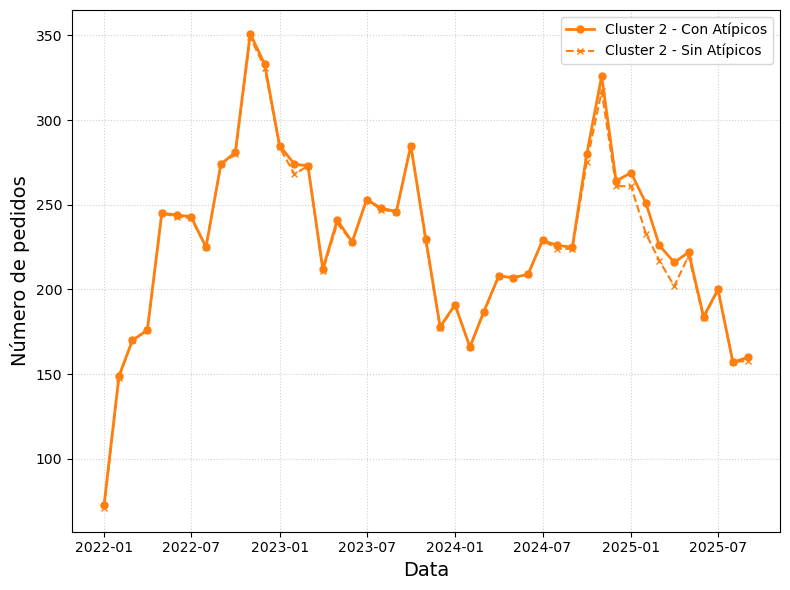

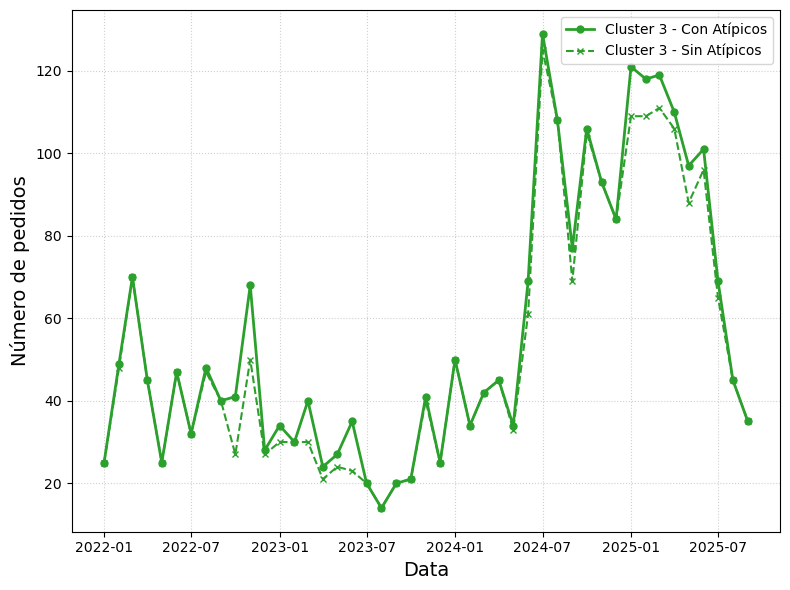

In [91]:
pedidos_por_mes_cluster_original = (
    datos
    .groupby(['mes', 'Cluster'])
    .size()
    .reset_index(name='n_pedidos_original')
)
pedidos_por_mes_cluster_original['mes'] = pd.to_datetime(pedidos_por_mes_cluster_original['mes'])


pedidos_por_mes_cluster_sin_out = (
    datos_sin_out
    .groupby(['mes', 'Cluster'])
    .size()
    .reset_index(name='n_pedidos_sin_out')
)
pedidos_por_mes_cluster_sin_out['mes'] = pd.to_datetime(pedidos_por_mes_cluster_sin_out['mes'])


unique_clusters = pedidos_por_mes_cluster_original['Cluster'].unique()
colors = {
    unique_clusters[0]: 'tab:blue',
    unique_clusters[1]: 'tab:orange',
    unique_clusters[2]: 'tab:green'
}

for cluster_id in unique_clusters:
    
    plt.figure(figsize=(8, 6))
    current_color = colors.get(cluster_id, 'black')
    
    original_data = pedidos_por_mes_cluster_original[pedidos_por_mes_cluster_original['Cluster'] == cluster_id].sort_values('mes')
    sin_out_data = pedidos_por_mes_cluster_sin_out[pedidos_por_mes_cluster_sin_out['Cluster'] == cluster_id].sort_values('mes')
    
    plt.plot(
        original_data['mes'],
        original_data['n_pedidos_original'], 
        marker='o',
        markersize=5,
        linewidth=2,
        linestyle='-',
        color=current_color,
        label=f'Cluster {cluster_id} - Con Atípicos'
    )

    plt.plot(
        sin_out_data['mes'],
        sin_out_data['n_pedidos_sin_out'],
        marker='x', 
        markersize=5,
        linewidth=1.5,
        linestyle='--', 
        color=current_color,
        label=f'Cluster {cluster_id} - Sin Atípicos'
    )
    
    plt.xlabel('Data', fontsize = 14)
    plt.ylabel('Número de pedidos', fontsize = 14)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

Para finalizar gárdanse e expórtanse os datos resultantes en csv: un para os datos completos e outro para os datos filtrados. Estes .csv empregaranse no resto de scripts.

In [95]:
datos.to_csv("TFM_datos_EDA.csv", index = False)
datos_sin_out.to_csv("TFM_datos_EDA_outliers.csv", index = False)